# 📊 Polymarket BTC Up/Down 5-min — ML Trading System

**Role:** Senior Quant ML Engineer · Prediction · Signal Generation · Backtest  

---

## Architecture

```
Raw Snapshots  ──►  Feature Engineering  ──►  Model Training
                                                   │
                                         ┌────────┬┴──────────┐
                                         │        │           │
                                        LR       GBT      GBT+Iso
                                                              │
                                                   P(UP) / P(DOWN)
                                                              │
                                                      EV Computation
                                                              │
                                                  Signal: LONG_UP / LONG_DOWN / NO_TRADE
                                                              │
                                                  Backtest ──► Equity Curve
```

## Anti-Leakage Guarantees
- Split by **market chronological order** — no market appears in two splits
- Imputation medians fitted on **train only**, applied to val/test
- Isotonic calibration fitted on **validation only**, never test
- Features use only variables observable at snapshot time
- `resolution` used only as label, never as a feature

---
## 1 · Imports & Configuration

In [82]:
# =============================================================================
# 1. IMPORTS & CONFIGURATION
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Configura pandas para que no haya límite en el número de columnas mostradas
pd.set_option('display.max_columns', None)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    brier_score_loss, log_loss, classification_report,
    roc_curve, precision_recall_curve,
)

# --- Optional: LightGBM / XGBoost -------------------------------------------
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print(f"LightGBM {lgb.__version__} available")
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed — using sklearn HistGradientBoostingClassifier.")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f"XGBoost {xgb.__version__} available")
except ImportError:
    XGB_AVAILABLE = False

# --- Reproducibility ---------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# --- Plot style ---------------------------------------------------------------
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

# --- Pipeline Configuration --------------------------------------------------
#   DATA_PATH: path to the CSV file (change if needed)
CFG = dict(
    DATA_PATH             = '../dataset_with_resolution.csv',
    # Split fractions — applied by market count, in chronological order
    TRAIN_FRAC            = 0.70,
    VAL_FRAC              = 0.15,
    # Remaining 15% -> test

    # Backtest
    INITIAL_CAPITAL       = 1_000.0,   # USDC
    STAKE                 = 10.0,      # reference stake (PnL uses pre-computed win/loss_net)
    EV_THRESHOLD          = 0.03,      # min expected value (USDC) to enter a trade
    MIN_PROB_EDGE         = 0.02,      # min P(direction) - break_even to enter
    ENTRY_WINDOW          = (0.05, 0.80),  # valid entry interval [progress_lo, progress_hi]
    MAX_TRADES_PER_MARKET = 1,         # enter at most once per market
)

print("\nConfiguration:")
for k, v in CFG.items():
    print(f"  {k:<28} = {v}")

LightGBM 4.6.0 available
XGBoost 3.2.0 available

Configuration:
  DATA_PATH                    = ../dataset_with_resolution.csv
  TRAIN_FRAC                   = 0.7
  VAL_FRAC                     = 0.15
  INITIAL_CAPITAL              = 1000.0
  STAKE                        = 10.0
  EV_THRESHOLD                 = 0.03
  MIN_PROB_EDGE                = 0.02
  ENTRY_WINDOW                 = (0.05, 0.8)
  MAX_TRADES_PER_MARKET        = 1


---
## 2 · Load Data

In [83]:
# =============================================================================
# 2. LOAD DATA
# =============================================================================
df_raw = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

# Normalise timezone to UTC
if df_raw['timestamp'].dt.tz is None:
    df_raw['timestamp'] = df_raw['timestamp'].dt.tz_localize('UTC')
else:
    df_raw['timestamp'] = df_raw['timestamp'].dt.tz_convert('UTC')

# Sort chronologically — mandatory for leakage-free split
df_raw = df_raw.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

print(f"{'Rows':<22}: {len(df_raw):,}")
print(f"{'Columns':<22}: {df_raw.shape[1]}")
print(f"{'Date range':<22}: {df_raw['timestamp'].min()}  to  {df_raw['timestamp'].max()}")
print(f"{'Markets':<22}: {df_raw['market_slug'].nunique():,}")
print(f"{'Resolution dist':<22}: {df_raw['resolution'].value_counts().to_dict()}")
print(f"{'Snapshots/market avg':<22}: {df_raw.groupby('market_slug').size().mean():.1f}")

df_raw.head(3)

Rows                  : 27,199
Columns               : 66
Date range            : 2026-03-19 16:15:55.759706+00:00  to  2026-03-20 15:52:37.610864+00:00
Markets               : 284
Resolution dist       : {'up': 13785, 'down': 13414}
Snapshots/market avg  : 95.8


,timestamp,market_slug,seconds_left,market_progress,btc_spot,btc_price_market_open,btc_return_since_open,up_bid_p_1,up_bid_s_1,up_ask_p_1,up_ask_s_1,up_bid_p_2,up_bid_s_2,up_ask_p_2,up_ask_s_2,up_bid_p_3,up_bid_s_3,up_ask_p_3,up_ask_s_3,down_bid_p_1,down_bid_s_1,down_ask_p_1,down_ask_s_1,down_bid_p_2,down_bid_s_2,down_ask_p_2,down_ask_s_2,down_bid_p_3,down_bid_s_3,down_ask_p_3,down_ask_s_3,up_fee_bps,down_fee_bps,up_avg_fill,up_win_net,up_loss_net,up_break_even,down_avg_fill,down_win_net,down_loss_net,down_break_even,market_liquid,bid_volume_10,ask_volume_10,orderbook_imbalance,mid_price,spread,ret_1m,ret_3m,ret_5m,ret_10m,ema_3,ema_6,ema_12,ema_24,ema_ratio,price_vs_ema12,volume_1m,volume_3m,volume_5m,volatility_3m,volatility_5m,buy_volume_last200,sell_volume_last200,trade_imbalance,resolution
0,2026-03-19 16:15:55.759706+00:00,btc-updown-5m-1773936900,246,0.1800,69365.42,69365.42,0.000000,0.59,13.18,0.60,651.47,0.58,61.82,0.61,837.45,0.57,140.0,0.62,1226.25,0.40,651.47,0.42,40.08,0.39,812.45,0.43,145.0,0.38,1226.25,0.44,477.75,10.0,10.0,0.60,6.656667,-10.01,0.60060,0.42,13.799524,-10.01,0.42042,1.0,7.53131,1.00543,0.764446,69365.415,0.01,0.000714,0.001272,0.001045,-0.000476,69306.635459,69300.76476,69316.730646,69319.588327,0.999854,1.000331,18.89866,56.53472,84.1646,0.000466,0.000469,0.01957,0.10452,-0.684584,down
1,2026-03-19 16:15:58.879491+00:00,btc-updown-5m-1773936900,242,0.1933,69355.41,69365.42,-0.000144,0.59,50.12,0.60,347.66,0.58,136.00,0.61,1548.49,0.57,83.0,0.62,995.00,0.40,422.66,0.41,40.12,0.39,1533.49,0.42,136.0,0.38,1075.00,0.43,83.00,10.0,10.0,0.60,6.656667,-10.01,0.60060,0.41,14.380244,-10.01,0.41041,1.0,0.34970,8.29136,-0.919061,69354.655,0.01,0.000714,0.001272,0.001045,-0.000476,69306.635459,69300.76476,69316.730646,69319.588327,0.999854,1.000331,18.89866,56.53472,84.1646,0.000466,0.000469,0.06983,0.16296,-0.400060,down
2,2026-03-19 16:16:01.972372+00:00,btc-updown-5m-1773936900,239,0.2033,69354.65,69365.42,-0.000155,0.55,629.00,0.56,257.61,0.54,1043.00,0.57,949.08,0.53,706.0,0.58,595.00,0.44,256.88,0.45,478.50,0.43,969.08,0.46,873.0,0.42,600.00,0.47,706.00,10.0,10.0,0.56,7.847143,-10.01,0.56056,0.45,12.212222,-10.01,0.45045,1.0,2.39225,1.91230,0.111498,69354.655,0.01,0.000216,0.001602,0.001153,0.000056,69330.647729,69316.16340,69322.565933,69322.396779,1.000117,1.000463,13.59213,46.80905,83.6352,0.000276,0.000466,0.05429,0.20869,-0.587117,down


---
## 3 · Cleaning & Validation

| Step | Action |
|---|---|
| Resolution consistency | Drop markets with >1 resolution value |
| Missing criticals | Drop rows missing `resolution`, `btc_spot`, `market_progress` |
| Inf / -Inf | Replace with NaN, then impute |
| Imputation | Column medians — re-fitted on train-only during modelling |
| Clipping | `market_progress` → [0, 1] |

In [84]:
# =============================================================================
# 3. CLEANING & VALIDATION
# =============================================================================
df = df_raw.copy()

# 3a. Verify resolution is unique per market
res_check   = df.groupby('market_slug')['resolution'].nunique()
bad_markets = res_check[res_check > 1].index.tolist()
if bad_markets:
    print(f"WARNING: {len(bad_markets)} markets with inconsistent resolution — dropping.")
    df = df[~df['market_slug'].isin(bad_markets)]
else:
    print("OK: Resolution is consistent per market.")

# 3b. Drop rows with missing critical fields
n_before = len(df)
df = df.dropna(subset=['resolution', 'btc_spot', 'market_progress'])
print(f"OK: Dropped {n_before - len(df)} rows with missing critical fields.")

# 3c. Replace inf/-inf with NaN
num_cols   = df.select_dtypes(include=[np.number]).columns
inf_count  = np.isinf(df[num_cols]).sum().sum()
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
print(f"OK: Replaced {inf_count} inf/-inf values with NaN.")

# 3d. NaN report
nan_report = df[num_cols].isnull().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)
print(f"\nNaN columns ({len(nan_report)} total):")
print(nan_report.to_frame('NaN count').assign(
    pct=lambda x: (x['NaN count'] / len(df) * 100).round(2)
).head(12).to_string())

# 3e. Global median imputation (overridden by train-only medians in modelling)
GLOBAL_MEDIANS = df[num_cols].median()
df[num_cols]   = df[num_cols].fillna(GLOBAL_MEDIANS)
assert df[num_cols].isnull().sum().sum() == 0, "NaNs remain after imputation!"
print("\nOK: All NaNs imputed with column medians.")

# 3f. Clip market_progress
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"\nClean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

OK: Resolution is consistent per market.
OK: Dropped 0 rows with missing critical fields.
OK: Replaced 0 inf/-inf values with NaN.

NaN columns (44 total):
              NaN count   pct
down_ask_s_3       2014  7.40
down_ask_p_3       2014  7.40
up_bid_p_3         2008  7.38
up_bid_s_3         2008  7.38
down_bid_s_3       1933  7.11
down_bid_p_3       1933  7.11
up_ask_p_3         1932  7.10
up_ask_s_3         1932  7.10
down_ask_s_2       1624  5.97
down_ask_p_2       1624  5.97
up_bid_s_2         1622  5.96
up_bid_p_2         1622  5.96

OK: All NaNs imputed with column medians.

Clean dataset: 27,199 rows x 66 columns


---
## 4 · Feature Engineering

All features derive **only from variables observable at snapshot time**.

| Group | Features |
|---|---|
| BTC price | return sign/magnitude vs open, binary direction flag |
| Momentum | per-period sign/magnitude, alignment score, short-vs-long divergence |
| EMA structure | pairwise ratios, golden-cross flag, price-vs-EMA24 flag |
| Polymarket UP/DOWN book | spread, mid, depth totals, order book imbalance, implied probs, market premium |
| Slippage proxy | avg_fill vs best ask |
| Market state | progress, progress², early/late flags |
| Volume | short-term acceleration, buy/sell ratio |
| Volatility | 3m/5m ratio, high-vol flag |
| Binance microstructure | bid/ask volume ratio |

> **Note on `ret_30s`:** documented in the data dictionary but absent from this CSV version. If present in future data it will be included automatically.

In [85]:
# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

# 4a. BTC price
fe['btc_return_sign']      = np.sign(fe['btc_return_since_open'])
fe['btc_return_abs']       = fe['btc_return_since_open'].abs()
fe['btc_vs_open_up']       = (fe['btc_return_since_open'] > 0).astype(int)

# 4b. Momentum
for col in ['ret_1m', 'ret_3m', 'ret_5m', 'ret_10m']:
    fe[f'{col}_sign'] = np.sign(fe[col])
    fe[f'{col}_abs']  = fe[col].abs()

if 'ret_30s' in fe.columns:   # include if present
    fe['ret_30s_sign'] = np.sign(fe['ret_30s'])
    fe['ret_30s_abs']  = fe['ret_30s'].abs()

fe['momentum_aligned']   = (
    (np.sign(fe['ret_1m']) == np.sign(fe['ret_3m'])) &
    (np.sign(fe['ret_1m']) == np.sign(fe['ret_5m']))
).astype(int)
fe['ret_short_vs_long']  = fe['ret_1m'] - fe['ret_10m']

# 4c. EMA structure
fe['ema_3_vs_6']         = fe['ema_3']  / (fe['ema_6']  + 1e-9) - 1
fe['ema_6_vs_12']        = fe['ema_6']  / (fe['ema_12'] + 1e-9) - 1
fe['ema_12_vs_24']       = fe['ema_12'] / (fe['ema_24'] + 1e-9) - 1
fe['ema_cross_up']       = (fe['ema_3'] > fe['ema_12']).astype(int)
fe['btc_above_ema24']    = (fe['btc_spot'] > fe['ema_24']).astype(int)

# 4d. Polymarket order book — UP
fe['up_spread']          = fe['up_ask_p_1'] - fe['up_bid_p_1']
fe['up_mid']             = (fe['up_ask_p_1'] + fe['up_bid_p_1']) / 2
fe['up_depth_bid']       = fe['up_bid_s_1'] + fe['up_bid_s_2'] + fe['up_bid_s_3']
fe['up_depth_ask']       = fe['up_ask_s_1'] + fe['up_ask_s_2'] + fe['up_ask_s_3']
fe['up_book_imbalance']  = (
    (fe['up_depth_bid'] - fe['up_depth_ask']) /
    (fe['up_depth_bid'] + fe['up_depth_ask'] + 1e-9)
)

# 4e. Polymarket order book — DOWN
fe['down_spread']        = fe['down_ask_p_1'] - fe['down_bid_p_1']
fe['down_mid']           = (fe['down_ask_p_1'] + fe['down_bid_p_1']) / 2
fe['down_depth_bid']     = fe['down_bid_s_1'] + fe['down_bid_s_2'] + fe['down_bid_s_3']
fe['down_depth_ask']     = fe['down_ask_s_1'] + fe['down_ask_s_2'] + fe['down_ask_s_3']
fe['down_book_imbalance']= (
    (fe['down_depth_bid'] - fe['down_depth_ask']) /
    (fe['down_depth_bid'] + fe['down_depth_ask'] + 1e-9)
)

# 4f. Market-implied probabilities & relative pricing
# Buying UP at ask p means risk-neutral implied P(UP) = p.
# 1 - ask = potential gain per dollar risked.
fe['up_implied_prob']    = 1 - fe['up_ask_p_1']
fe['down_implied_prob']  = 1 - fe['down_ask_p_1']
fe['market_up_premium']  = fe['up_ask_p_1'] - fe['down_ask_p_1']   # + => market leans UP

# 4g. Slippage proxy
fe['up_slippage']        = fe['up_avg_fill']   - fe['up_ask_p_1']
fe['down_slippage']      = fe['down_avg_fill'] - fe['down_ask_p_1']

# 4h. Market state
fe['market_progress_sq'] = fe['market_progress'] ** 2
fe['market_progress_late']  = (fe['market_progress'] > 0.70).astype(int)
fe['market_progress_early'] = (fe['market_progress'] < 0.30).astype(int)

# 4i. Volume
fe['volume_accel']       = fe['volume_1m'] / (fe['volume_3m'] / 3 + 1e-9)
fe['buy_sell_ratio']     = fe['buy_volume_last200'] / (fe['sell_volume_last200'] + 1e-9)

# 4j. Volatility
fe['vol_ratio']          = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)
fe['high_vol_flag']      = (fe['volatility_5m'] > fe['volatility_5m'].median()).astype(int)

# 4k. Binance microstructure
fe['binance_bid_ask_ratio'] = fe['bid_volume_10'] / (fe['ask_volume_10'] + 1e-9)

# 4l. Stake reference: -loss_net = stake + fee (approx. amount at risk)
fe['stake_up']           = -fe['up_loss_net']
fe['stake_down']         = -fe['down_loss_net']

# 4m. Winsorise continuous engineered features at 1%/99%
BINARY_SET = {
    'momentum_aligned', 'btc_vs_open_up', 'ema_cross_up', 'btc_above_ema24',
    'market_progress_late', 'market_progress_early', 'high_vol_flag',
    'ret_1m_sign', 'ret_3m_sign', 'ret_5m_sign', 'ret_10m_sign', 'btc_return_sign',
}
ENGINEERED = [
    'btc_return_sign','btc_return_abs','btc_vs_open_up',
    'ret_1m_sign','ret_1m_abs','ret_3m_sign','ret_3m_abs',
    'ret_5m_sign','ret_5m_abs','ret_10m_sign','ret_10m_abs',
    'momentum_aligned','ret_short_vs_long',
    'ema_3_vs_6','ema_6_vs_12','ema_12_vs_24','ema_cross_up','btc_above_ema24',
    'up_spread','up_mid','up_depth_bid','up_depth_ask','up_book_imbalance',
    'down_spread','down_mid','down_depth_bid','down_depth_ask','down_book_imbalance',
    'up_implied_prob','down_implied_prob','market_up_premium',
    'up_slippage','down_slippage',
    'market_progress_sq','market_progress_late','market_progress_early',
    'volume_accel','buy_sell_ratio',
    'vol_ratio','high_vol_flag',
    'binance_bid_ask_ratio','stake_up','stake_down',
]
if 'ret_30s' in fe.columns:
    ENGINEERED += ['ret_30s_sign','ret_30s_abs']

for c in ENGINEERED:
    if c in BINARY_SET or fe[c].nunique() <= 2:
        continue
    lo, hi = fe[c].quantile(0.01), fe[c].quantile(0.99)
    fe[c] = fe[c].clip(lo, hi)

print(f"Engineered features added : {len(ENGINEERED)}")
print(f"Total columns             : {fe.shape[1]}")

Engineered features added : 43
Total columns             : 109


---
## 5 · Target Definition

| `y` | Meaning |
|---|---|
| 1 | Market resolves **UP** |
| 0 | Market resolves **DOWN** |

In [86]:
# =============================================================================
# 5. TARGET DEFINITION
# =============================================================================
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

mkt_target = fe.groupby('market_slug')['y'].first().value_counts()
print("Market-level distribution:")
print(f"  UP   markets : {mkt_target.get(1,0):>5}  ({mkt_target.get(1,0)/mkt_target.sum():.1%})")
print(f"  DOWN markets : {mkt_target.get(0,0):>5}  ({mkt_target.get(0,0)/mkt_target.sum():.1%})")
print(f"\nSnapshot-level distribution:")
print(f"  UP   rows    : {(fe['y']==1).sum():>7,}  ({(fe['y']==1).mean():.1%})")
print(f"  DOWN rows    : {(fe['y']==0).sum():>7,}  ({(fe['y']==0).mean():.1%})")

Market-level distribution:
  UP   markets :   145  (51.1%)
  DOWN markets :   139  (48.9%)

Snapshot-level distribution:
  UP   rows    :  13,785  (50.7%)
  DOWN rows    :  13,414  (49.3%)


---
## 6 · Temporal Split by Market

```
Oldest markets ──────────────────────────────────► Newest markets
│────── 70 % TRAIN ──────│── 15 % VAL ──│── 15 % TEST ──│
```

In [87]:
# =============================================================================
# 6. TEMPORAL SPLIT BY MARKET
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)

N          = len(market_order)
n_train    = int(N * CFG['TRAIN_FRAC'])
n_val      = int(N * CFG['VAL_FRAC'])

train_markets = market_order[:n_train]
val_markets   = market_order[n_train : n_train + n_val]
test_markets  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_markets)].copy()
va = fe[fe['market_slug'].isin(val_markets)].copy()
te = fe[fe['market_slug'].isin(test_markets)].copy()

# Leakage assertions
assert tr['timestamp'].max() < va['timestamp'].min(), "LEAKAGE: train/val overlap!"
assert va['timestamp'].max() < te['timestamp'].min(), "LEAKAGE: val/test overlap!"
print("Zero temporal leakage confirmed.")

print(f"\n{'Split':<10} {'Markets':>8} {'Rows':>8} {'UP%':>6}  {'Date range'}")
print("-" * 72)
for name, split in [('Train', tr), ('Validation', va), ('Test', te)]:
    n_m = split['market_slug'].nunique()
    upr = split['y'].mean()
    d0  = split['timestamp'].min().strftime('%Y-%m-%d %H:%M')
    d1  = split['timestamp'].max().strftime('%Y-%m-%d %H:%M')
    print(f"{name:<10} {n_m:>8,} {len(split):>8,} {upr:>6.1%}  {d0} -> {d1}")

Zero temporal leakage confirmed.

Split       Markets     Rows    UP%  Date range
------------------------------------------------------------------------
Train           198   18,981  51.2%  2026-03-19 16:15 -> 2026-03-20 08:44
Validation       42    4,040  49.7%  2026-03-20 08:45 -> 2026-03-20 12:14
Test             44    4,178  49.2%  2026-03-20 12:15 -> 2026-03-20 15:52


---
## 7 · Feature Matrix Preparation

In [88]:
# =============================================================================
# 7. FEATURE MATRIX PREPARATION
# =============================================================================
# Excluded: identifiers, target, raw EMA prices (replaced by ratio features)
EXCLUDE = {
    'timestamp', 'market_slug', 'resolution', 'y',
    'ema_3', 'ema_6', 'ema_12', 'ema_24',
}
FEATURES = [c for c in fe.columns if c not in EXCLUDE]
print(f"Feature set: {len(FEATURES)} features")

def safe_impute(arr_or_df, medians, features=FEATURES):
    d = (arr_or_df if isinstance(arr_or_df, pd.DataFrame)
         else pd.DataFrame(arr_or_df, columns=features))
    return d.replace([np.inf, -np.inf], np.nan).fillna(medians).values

# Fit medians on TRAIN ONLY
TRAIN_MEDIANS = pd.DataFrame(
    tr[FEATURES].values, columns=FEATURES
).median()

X_tr = safe_impute(tr[FEATURES].values, TRAIN_MEDIANS); y_tr = tr['y'].values
X_va = safe_impute(va[FEATURES].values, TRAIN_MEDIANS); y_va = va['y'].values
X_te = safe_impute(te[FEATURES].values, TRAIN_MEDIANS); y_te = te['y'].values

for split_name, X in [('X_tr', X_tr), ('X_va', X_va), ('X_te', X_te)]:
    assert not np.any(np.isnan(X)), f"NaNs remain in {split_name}!"

print(f"X_tr: {X_tr.shape}  X_va: {X_va.shape}  X_te: {X_te.shape}")

Feature set: 102 features
X_tr: (18981, 102)  X_va: (4040, 102)  X_te: (4178, 102)


---
## 8 · Model Training

| # | Model | Key property |
|---|---|---|
| 1 | Logistic Regression | Interpretable baseline; requires StandardScaler |
| 2 | GBT (LightGBM / sklearn) | Non-linear, handles interactions; raw probabilities may be overconfident |
| 3 | GBT + Isotonic Calibration | Corrects probability overconfidence via monotonic regression on val set |

**Calibration note:** `IsotonicRegression` is fitted on the **validation set only** (never test), mapping GBT raw scores to calibrated probabilities. This is equivalent to `CalibratedClassifierCV(cv='prefit')` but works across all sklearn versions.

In [89]:
# =============================================================================
# 8. MODEL TRAINING
# =============================================================================

# --- Model 1: Logistic Regression (baseline) ---------------------------------
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        C=0.1, max_iter=2000, solver='lbfgs',
        class_weight='balanced', random_state=SEED
    ))
])
pipe_lr.fit(X_tr, y_tr)
print("[1] Logistic Regression trained")

# --- Model 2: Gradient Boosted Trees -----------------------------------------
if LGBM_AVAILABLE:
    gbt = lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        num_leaves=31, min_child_samples=30,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=SEED, n_jobs=-1, verbose=-1,
    )
    gbt.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    print(f"[2] LightGBM trained  (best iter: {gbt.best_iteration_})")
elif XGB_AVAILABLE:
    gbt = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=SEED, eval_metric='logloss',
        early_stopping_rounds=50, verbosity=0, n_jobs=-1,
    )
    gbt.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    print("[2] XGBoost trained")
else:
    gbt = HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=5,
        min_samples_leaf=30, l2_regularization=0.1,
        random_state=SEED,
    )
    gbt.fit(X_tr, y_tr)
    print("[2] HistGradientBoostingClassifier trained")

# --- Model 3: Isotonic Calibration on Val set --------------------------------
# Map raw GBT P(UP) to calibrated P(UP) via isotonic regression.
# Val set is NEVER seen by gbt.fit().
p_va_raw = gbt.predict_proba(X_va)[:, 1]
iso_cal  = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(p_va_raw, y_va)

class CalibratedModel:
    """GBT + post-hoc isotonic calibration."""
    def __init__(self, base, calibrator):
        self.base = base
        self.calibrator = calibrator
    def predict_proba(self, X):
        p_raw = self.base.predict_proba(X)[:, 1]
        p_cal = self.calibrator.transform(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

cal_gbt = CalibratedModel(gbt, iso_cal)
print("[3] GBT + Isotonic Calibration ready")

[1] Logistic Regression trained
[2] LightGBM trained  (best iter: 54)
[3] GBT + Isotonic Calibration ready


---
## 9 · Evaluation

Comparison on validation (model selection) and test (final evaluation).

In [90]:
# =============================================================================
# 9. EVALUATION
# =============================================================================
def evaluate(name, model, X, y):
    p    = model.predict_proba(X)[:, 1]
    pred = (p >= 0.5).astype(int)
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y, pred),       4),
        'ROC AUC'  : round(roc_auc_score(y, p),           4),
        'PR AUC'   : round(average_precision_score(y, p), 4),
        'Log-loss' : round(log_loss(y, p),                4),
        'Brier'    : round(brier_score_loss(y, p),        4),
    }

MODELS = {
    'Logistic Regression': pipe_lr,
    'GBT'                : gbt,
    'GBT + Calibration'  : cal_gbt,
}

df_val_eval  = pd.DataFrame([evaluate(n,m,X_va,y_va) for n,m in MODELS.items()]).set_index('Model')
df_test_eval = pd.DataFrame([evaluate(n,m,X_te,y_te) for n,m in MODELS.items()]).set_index('Model')

print("VALIDATION SET:")
print(df_val_eval.to_string())
print("\nTEST SET (hold-out):")
print(df_test_eval.to_string())

BEST_NAME  = df_val_eval['ROC AUC'].idxmax()
BEST_MODEL = MODELS[BEST_NAME]
print(f"\nBest model (val ROC AUC): {BEST_NAME}")

p_best = BEST_MODEL.predict_proba(X_te)[:, 1]
print("\nClassification report (test set):")
print(classification_report(y_te, (p_best >= 0.5).astype(int), target_names=['DOWN','UP']))

VALIDATION SET:
                     Accuracy  ROC AUC  PR AUC  Log-loss   Brier
Model                                                           
Logistic Regression    0.7851   0.8833  0.8902    0.4232  0.1420
GBT                    0.8240   0.9028  0.9043    0.3937  0.1246
GBT + Calibration      0.8282   0.9087  0.8981    0.3677  0.1187

TEST SET (hold-out):
                     Accuracy  ROC AUC  PR AUC  Log-loss   Brier
Model                                                           
Logistic Regression    0.7348   0.8152  0.8029    0.6460  0.1924
GBT                    0.7046   0.7984  0.8028    0.5890  0.1993
GBT + Calibration      0.6953   0.7973  0.7720    0.9548  0.2030

Best model (val ROC AUC): GBT + Calibration

Classification report (test set):
              precision    recall  f1-score   support

        DOWN       0.70      0.71      0.70      2123
          UP       0.69      0.68      0.69      2055

    accuracy                           0.70      4178
   macro avg  

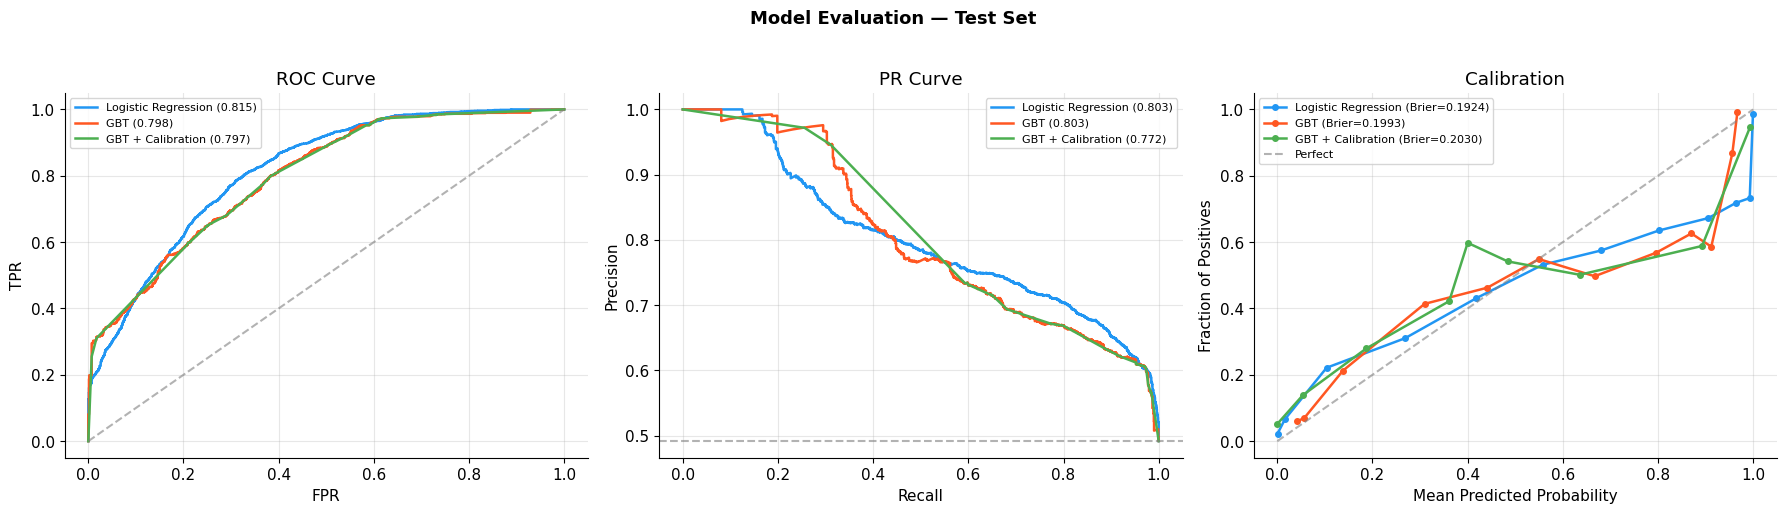

In [91]:
# --- ROC, PR, Calibration curves -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for (name, model), c in zip(MODELS.items(), COLORS):
    p = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_te, p)
    axes[0].plot(fpr, tpr, color=c, lw=1.8, label=f"{name} ({roc_auc_score(y_te,p):.3f})")

    prec, rec, _ = precision_recall_curve(y_te, p)
    axes[1].plot(rec, prec, color=c, lw=1.8, label=f"{name} ({average_precision_score(y_te,p):.3f})")

    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=12, strategy='quantile')
    axes[2].plot(mean_pred, frac_pos, 'o-', color=c, lw=1.8, ms=4,
                 label=f"{name} (Brier={brier_score_loss(y_te,p):.4f})")

axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.6)
axes[0].set(title='ROC Curve', xlabel='FPR', ylabel='TPR'); axes[0].legend(fontsize=8)

axes[1].axhline(y_te.mean(), ls='--', color='gray', alpha=0.6)
axes[1].set(title='PR Curve', xlabel='Recall', ylabel='Precision'); axes[1].legend(fontsize=8)

axes[2].plot([0,1],[0,1],'--',color='gray',alpha=0.6,label='Perfect')
axes[2].set(title='Calibration', xlabel='Mean Predicted Probability',
            ylabel='Fraction of Positives'); axes[2].legend(fontsize=8)

plt.suptitle('Model Evaluation — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('png/01_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10 · Expected Value Computation

$$\text{EV}_{\text{UP}} = p_{\text{UP}} \times \text{up\_win\_net} + (1 - p_{\text{UP}}) \times \text{up\_loss\_net}$$

$$\text{EV}_{\text{DOWN}} = p_{\text{DOWN}} \times \text{down\_win\_net} + p_{\text{UP}} \times \text{down\_loss\_net}$$

All `win_net` / `loss_net` values **already include fees**. Break-even edges:

$$\text{edge}_{\text{UP}} = p_{\text{UP}} - \text{up\_break\_even}$$

EV / Edge stats (test set):
            p_up     p_down      ev_up    ev_down    edge_up   edge_down
count  4178.0000  4178.0000  4178.0000  4178.0000  4178.0000   4178.0000
mean      0.5470     0.4530     2.5574     0.3433     0.0689    -16.7539
std       0.3634     0.3634    21.5835   129.6044     0.1861   1081.0261
min       0.0000     0.0000   -10.0100   -10.0100    -0.4709 -69874.8002
25%       0.3127     0.1042    -2.5512    -7.3372    -0.0521     -0.1399
50%       0.4847     0.5153     0.4067    -0.8456     0.0264     -0.0200
75%       0.8958     0.6873     3.8268     1.2563     0.1550      0.0704
max       1.0000     1.0000   851.4132  8362.0167     0.6516      0.4995


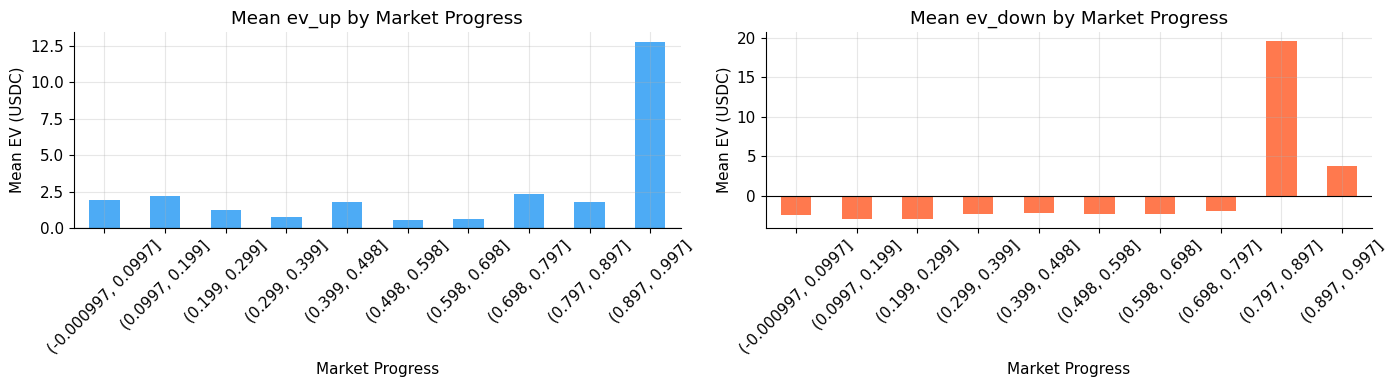

In [92]:
# =============================================================================
# 10. EXPECTED VALUE COMPUTATION
# =============================================================================
X_all      = safe_impute(fe[FEATURES].values, TRAIN_MEDIANS)
fe['p_up'] = BEST_MODEL.predict_proba(X_all)[:, 1]
fe['p_down']= 1.0 - fe['p_up']

fe['ev_up']   = fe['p_up']   * fe['up_win_net']   + fe['p_down'] * fe['up_loss_net']
fe['ev_down'] = fe['p_down'] * fe['down_win_net'] + fe['p_up']   * fe['down_loss_net']

fe['roi_up']   = fe['ev_up']   / fe['stake_up'].clip(lower=1e-6)
fe['roi_down'] = fe['ev_down'] / fe['stake_down'].clip(lower=1e-6)

fe['edge_up']  = fe['p_up']   - fe['up_break_even']
fe['edge_down']= fe['p_down'] - fe['down_break_even']

test_fe = fe[fe['market_slug'].isin(test_markets)].copy()
print("EV / Edge stats (test set):")
print(test_fe[['p_up','p_down','ev_up','ev_down',
               'edge_up','edge_down']].describe().round(4).to_string())

# EV by market progress
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, c in zip(axes, ['ev_up','ev_down'], [COLORS[0], COLORS[1]]):
    grp = test_fe.copy()
    grp['_bin'] = pd.cut(grp['market_progress'], bins=10)
    grp.groupby('_bin', observed=True)[col].mean().plot.bar(ax=ax, color=c, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Mean {col} by Market Progress')
    ax.set_xlabel('Market Progress'); ax.set_ylabel('Mean EV (USDC)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('png/02_ev_by_progress.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11 · Signal Generation

```
1. market_progress in [WL, WH]?          → else: NO_TRADE
2. ev_up   > EV_T AND edge_up   > EDGE_T → candidate LONG_UP
3. ev_down > EV_T AND edge_down > EDGE_T → candidate LONG_DOWN
4. Both candidates? → higher EV wins
5. Else: NO_TRADE
```

In [93]:
# =============================================================================
# 11. SIGNAL GENERATION
# =============================================================================
EV_T   = CFG['EV_THRESHOLD']
EDGE_T = CFG['MIN_PROB_EDGE']
WL, WH = CFG['ENTRY_WINDOW']

def generate_signal(ev_up, ev_down, edge_up, edge_down, progress,
                    ev_t=EV_T, edge_t=EDGE_T, wl=WL, wh=WH):
    if not (wl <= progress <= wh):  return 'NO_TRADE'
    up_ok   = (ev_up   > ev_t) and (edge_up   > edge_t)
    down_ok = (ev_down > ev_t) and (edge_down > edge_t)
    if up_ok and down_ok:
        return 'LONG_UP' if ev_up >= ev_down else 'LONG_DOWN'
    elif up_ok:   return 'LONG_UP'
    elif down_ok: return 'LONG_DOWN'
    return 'NO_TRADE'

fe['signal'] = [
    generate_signal(r.ev_up, r.ev_down, r.edge_up, r.edge_down, r.market_progress)
    for r in fe[['ev_up','ev_down','edge_up','edge_down','market_progress']].itertuples()
]

test_fe = fe[fe['market_slug'].isin(test_markets)].copy()

print("Signal distribution — all data:")
print(fe['signal'].value_counts().to_frame().assign(
    pct=lambda x: (x['count'] / len(fe) * 100).round(1)
).to_string())
print(f"\nOverall trade rate : {(fe['signal']!='NO_TRADE').mean():.2%}")

Signal distribution — all data:
           count   pct
signal                
NO_TRADE    9413  34.6
LONG_DOWN   9040  33.2
LONG_UP     8746  32.2

Overall trade rate : 65.39%


---
## 12 · Backtest Simulation

**Rules:** one trade per market at first valid signal; PnL uses pre-computed `win_net`/`loss_net` (fees embedded); exit at resolution.

In [94]:
# =============================================================================
# 12. BACKTEST ENGINE
# =============================================================================
def run_backtest(snapshot_df, initial_capital=1000.0, max_per_market=1):
    sdf     = snapshot_df.sort_values('timestamp').reset_index(drop=True)
    trades  = []
    entered = {}

    for _, row in sdf.iterrows():
        mkt = row['market_slug']
        sig = row['signal']
        if entered.get(mkt, 0) >= max_per_market or sig == 'NO_TRADE':
            continue

        is_up  = (sig == 'LONG_UP')
        actual = int(row['y'])
        won    = (actual == 1) if is_up else (actual == 0)

        if is_up:
            pnl = row['up_win_net']   if won else row['up_loss_net']
            fill, be, ev, p = row['up_avg_fill'], row['up_break_even'], row['ev_up'], row['p_up']
        else:
            pnl = row['down_win_net'] if won else row['down_loss_net']
            fill, be, ev, p = row['down_avg_fill'], row['down_break_even'], row['ev_down'], row['p_down']

        trades.append({
            'timestamp'       : row['timestamp'],
            'market_slug'     : mkt,
            'signal'          : sig,
            'resolution'      : row['resolution'],
            'market_progress' : row['market_progress'],
            'fill_price'      : fill,
            'p_predicted'     : p,
            'ev_entry'        : ev,
            'break_even'      : be,
            'won'             : won,
            'pnl'             : pnl,
        })
        entered[mkt] = entered.get(mkt, 0) + 1

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity']         = initial_capital + tdf['cumulative_pnl']

    eq_s = pd.concat([
        pd.Series([initial_capital], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, eq_s


def compute_stats(tdf, eq_s, initial_capital):
    if tdf.empty:
        print("No trades."); return {}
    n   = len(tdf); nw = tdf['won'].sum(); wr = nw / n
    gp  = tdf[tdf['pnl']>0]['pnl'].sum()
    gl  = tdf[tdf['pnl']<0]['pnl'].abs().sum()
    pf  = gp / (gl + 1e-9)
    pnl = tdf['pnl'].sum(); roi = pnl / initial_capital
    eq_arr = eq_s.values; rm = np.maximum.accumulate(eq_arr)
    mdd    = ((eq_arr - rm) / rm).min()
    pa     = tdf['pnl'].values
    sharpe = (pa.mean() / (pa.std() + 1e-9)) * np.sqrt(n)

    stats = dict(n=n, win_rate=wr, profit_factor=pf,
                 total_pnl=pnl, roi=roi,
                 avg_pnl=pa.mean(),
                 avg_win=tdf[tdf['won']]['pnl'].mean() if nw>0 else 0,
                 avg_loss=tdf[~tdf['won']]['pnl'].mean() if nw<n else 0,
                 max_drawdown=mdd, sharpe=sharpe,
                 final_equity=eq_s.iloc[-1])

    print("=" * 50)
    print(" BACKTEST SUMMARY — Test Set")
    print("=" * 50)
    print(f"  N Trades         : {n}")
    print(f"  Win Rate         : {wr:.2%}  ({nw}W / {n-nw}L)")
    print(f"  Profit Factor    : {pf:.3f}")
    print(f"  Total PnL        : {pnl:+.2f} USDC")
    print(f"  ROI (total)      : {roi:.2%}")
    print(f"  Avg PnL / trade  : {pa.mean():.4f} USDC")
    print(f"  Avg Win          : {stats['avg_win']:.4f} USDC")
    print(f"  Avg Loss         : {stats['avg_loss']:.4f} USDC")
    print(f"  Max Drawdown     : {mdd:.2%}")
    print(f"  Sharpe (simple)  : {sharpe:.3f}")
    print(f"  Final Equity     : {eq_s.iloc[-1]:.2f} USDC")
    print("\n  By direction:")
    print(tdf.groupby('signal').agg(
        n=('pnl','count'), total_pnl=('pnl','sum'), win_rate=('won','mean')
    ).round(4).to_string())
    return stats


trade_log, equity = run_backtest(
    test_fe, CFG['INITIAL_CAPITAL'], CFG['MAX_TRADES_PER_MARKET']
)
bt_stats = compute_stats(trade_log, equity, CFG['INITIAL_CAPITAL'])

 BACKTEST SUMMARY — Test Set
  N Trades         : 44
  Win Rate         : 52.27%  (23W / 21L)
  Profit Factor    : 1.161
  Total PnL        : +33.92 USDC
  ROI (total)      : 3.39%
  Avg PnL / trade  : 0.7710 USDC
  Avg Win          : 10.6145 USDC
  Avg Loss         : -10.0100 USDC
  Max Drawdown     : -6.60%
  Sharpe (simple)  : 0.447
  Final Equity     : 1033.92 USDC

  By direction:
            n  total_pnl  win_rate
signal                            
LONG_DOWN  21    13.2279    0.5238
LONG_UP    23    20.6966    0.5217


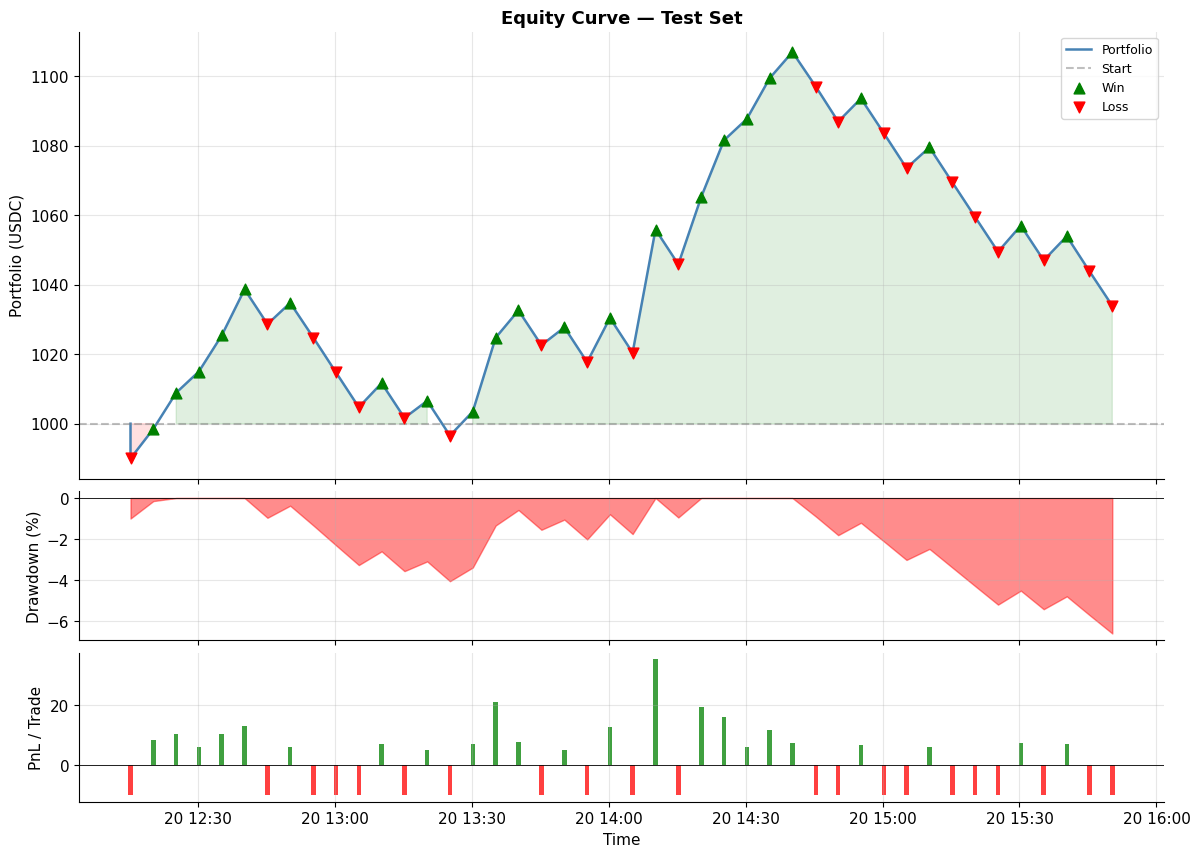

In [95]:
# --- Equity Curve + Drawdown + Trade-level PnL bars -------------------------
if not trade_log.empty:
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.05)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)

    ax0.plot(equity.index, equity.values, color='steelblue', lw=1.8, label='Portfolio')
    ax0.axhline(CFG['INITIAL_CAPITAL'], ls='--', color='gray', alpha=0.5, label='Start')
    ax0.fill_between(equity.index, CFG['INITIAL_CAPITAL'], equity.values,
                     where=equity.values >= CFG['INITIAL_CAPITAL'], alpha=0.12, color='green')
    ax0.fill_between(equity.index, CFG['INITIAL_CAPITAL'], equity.values,
                     where=equity.values < CFG['INITIAL_CAPITAL'], alpha=0.12, color='red')
    wins_df  = trade_log[trade_log['won']]
    loses_df = trade_log[~trade_log['won']]
    ax0.scatter(wins_df['timestamp'],  wins_df['equity'],  marker='^', s=60, color='green', zorder=5, label='Win')
    ax0.scatter(loses_df['timestamp'], loses_df['equity'], marker='v', s=60, color='red',   zorder=5, label='Loss')
    ax0.set_ylabel('Portfolio (USDC)')
    ax0.set_title('Equity Curve — Test Set', fontsize=13, fontweight='bold')
    ax0.legend(fontsize=9)
    plt.setp(ax0.get_xticklabels(), visible=False)

    eq_arr = equity.values; rm = np.maximum.accumulate(eq_arr)
    dd_pct = (eq_arr - rm) / rm * 100
    ax1.fill_between(equity.index, dd_pct, 0, color='red', alpha=0.45)
    ax1.axhline(0, color='black', lw=0.6)
    ax1.set_ylabel('Drawdown (%)')
    plt.setp(ax1.get_xticklabels(), visible=False)

    colors_bar = ['green' if p > 0 else 'red' for p in trade_log['pnl']]
    ax2.bar(trade_log['timestamp'], trade_log['pnl'],
            color=colors_bar, alpha=0.75, width=pd.Timedelta(seconds=60))
    ax2.axhline(0, color='black', lw=0.6)
    ax2.set_ylabel('PnL / Trade'); ax2.set_xlabel('Time')

    plt.savefig('png/03_equity_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

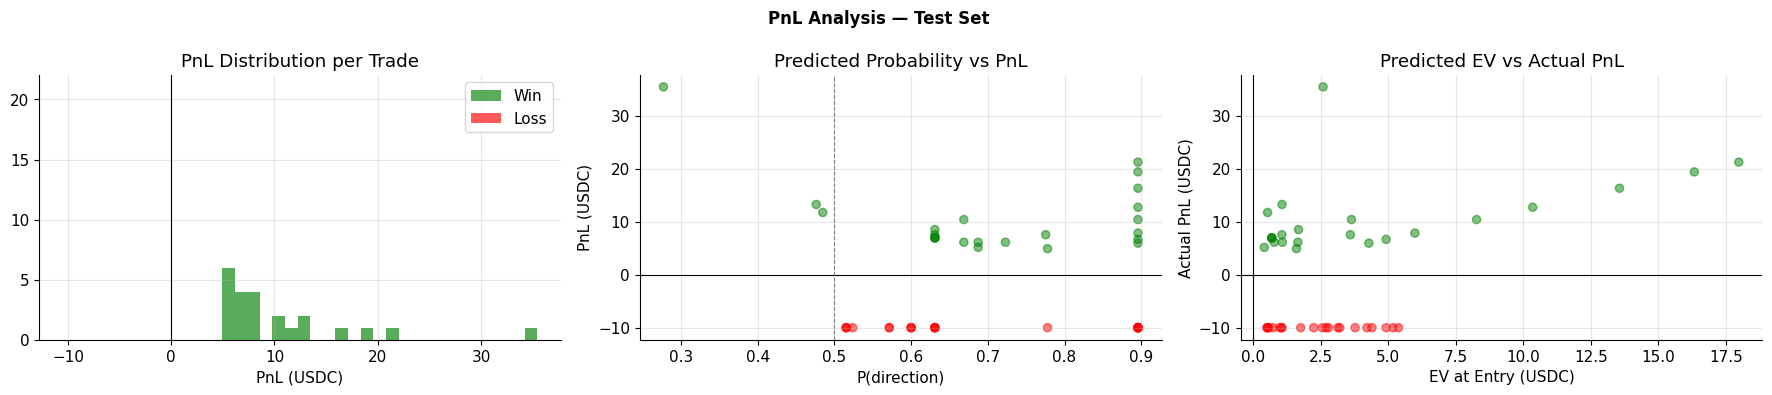

In [96]:
# --- PnL distribution & scatter plots ----------------------------------------
if not trade_log.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(wins_df['pnl'],  bins=25, alpha=0.65, color='green', label='Win')
    axes[0].hist(loses_df['pnl'], bins=25, alpha=0.65, color='red',   label='Loss')
    axes[0].axvline(0, color='black', lw=0.8)
    axes[0].set_title('PnL Distribution per Trade')
    axes[0].set_xlabel('PnL (USDC)'); axes[0].legend()

    c_arr = ['green' if w else 'red' for w in trade_log['won']]
    axes[1].scatter(trade_log['p_predicted'], trade_log['pnl'], c=c_arr, alpha=0.5, s=35)
    axes[1].axhline(0, color='black', lw=0.8); axes[1].axvline(0.5, ls='--', color='gray', lw=0.8)
    axes[1].set_title('Predicted Probability vs PnL')
    axes[1].set_xlabel('P(direction)'); axes[1].set_ylabel('PnL (USDC)')

    axes[2].scatter(trade_log['ev_entry'], trade_log['pnl'], c=c_arr, alpha=0.5, s=35)
    axes[2].axhline(0, color='black', lw=0.8); axes[2].axvline(0, color='black', lw=0.8)
    axes[2].set_title('Predicted EV vs Actual PnL')
    axes[2].set_xlabel('EV at Entry (USDC)'); axes[2].set_ylabel('Actual PnL (USDC)')

    plt.suptitle('PnL Analysis — Test Set', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('png/04_pnl_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 13 · Sensitivity Analysis — EV & Edge Thresholds

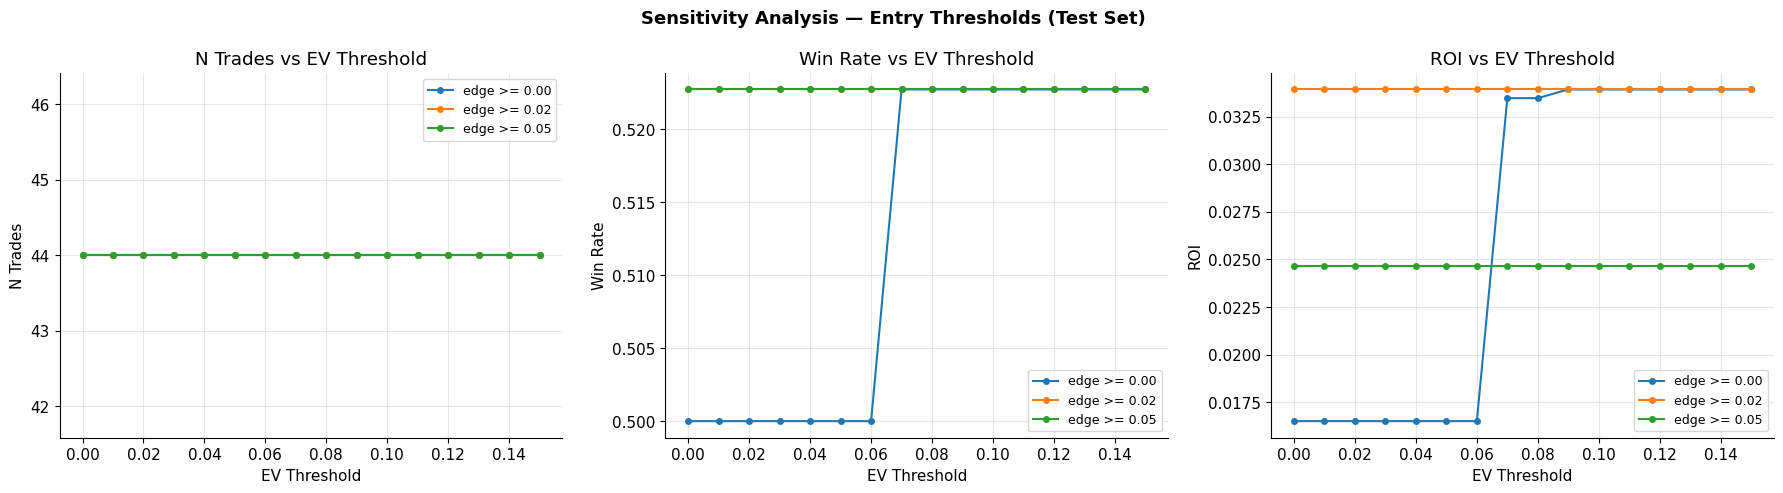

Best ROI operating point:
ev_t       0.000000
edge_t     0.020000
n         44.000000
wr         0.522727
roi        0.033925
pf         1.161384


In [97]:
# =============================================================================
# 13. SENSITIVITY ANALYSIS
# =============================================================================
ev_grid   = np.linspace(0.00, 0.15, 16)
edge_grid = [0.00, 0.02, 0.05]

sens_rows = []
for ev_t in ev_grid:
    for edge_t in edge_grid:
        tmp = test_fe.copy()
        tmp['signal'] = [
            generate_signal(r.ev_up, r.ev_down, r.edge_up, r.edge_down, r.market_progress,
                            ev_t=ev_t, edge_t=edge_t)
            for r in tmp[['ev_up','ev_down','edge_up','edge_down','market_progress']].itertuples()
        ]
        tl, _ = run_backtest(tmp, CFG['INITIAL_CAPITAL'])
        if tl.empty:
            sens_rows.append({'ev_t': round(ev_t,3), 'edge_t': edge_t,
                              'n': 0, 'wr': np.nan, 'roi': np.nan, 'pf': np.nan})
        else:
            gp2 = tl[tl['pnl']>0]['pnl'].sum()
            gl2 = tl[tl['pnl']<0]['pnl'].abs().sum()
            sens_rows.append({'ev_t': round(ev_t,3), 'edge_t': edge_t,
                              'n': len(tl), 'wr': tl['won'].mean(),
                              'roi': tl['pnl'].sum() / CFG['INITIAL_CAPITAL'],
                              'pf': gp2 / (gl2 + 1e-9)})

df_sens = pd.DataFrame(sens_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ycol, title in zip(axes, ['n','wr','roi'],
                            ['N Trades', 'Win Rate', 'ROI']):
    for edge_t, grp in df_sens.groupby('edge_t'):
        g = grp.sort_values('ev_t')
        ax.plot(g['ev_t'], g[ycol], marker='o', ms=4, label=f'edge >= {edge_t:.2f}')
    ax.set_title(f'{title} vs EV Threshold'); ax.set_xlabel('EV Threshold')
    ax.set_ylabel(title); ax.legend(fontsize=9)

plt.suptitle('Sensitivity Analysis — Entry Thresholds (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/05_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

best_pt = df_sens.loc[df_sens['roi'].idxmax()]
print(f"Best ROI operating point:\n{best_pt.to_string()}")

---
## 14 · Interpretability — Feature Importance

Three complementary views:
1. **Permutation importance** (model-agnostic, ROC AUC drop on test set)
2. **Native GBT importance** (split gain, when available)
3. **Logistic Regression coefficients** (signed, fully interpretable)

Calculando importancia por permutación (20 repeticiones, 102 features)...
AUC base (test): 0.7973

Top 25 features — caída en AUC al permutar:
btc_return_since_open    0.07669
down_ask_p_2             0.02413
up_mid                   0.01195
down_mid                 0.00917
market_up_premium        0.00769
up_avg_fill              0.00551
seconds_left             0.00356
volume_5m                0.00317
up_ask_p_2               0.00265
down_bid_p_3             0.00256
volume_1m                0.00223
ret_3m                   0.00211
ret_5m_abs               0.00197
volatility_5m            0.00186
ret_1m                   0.00148
up_ask_p_3               0.00090
btc_price_market_open    0.00088
up_bid_p_2               0.00062
vol_ratio                0.00053
up_bid_p_1               0.00043
down_ask_p_3             0.00033
down_bid_p_2             0.00033
mid_price                0.00030
price_vs_ema12           0.00028
ret_3m_abs               0.00024


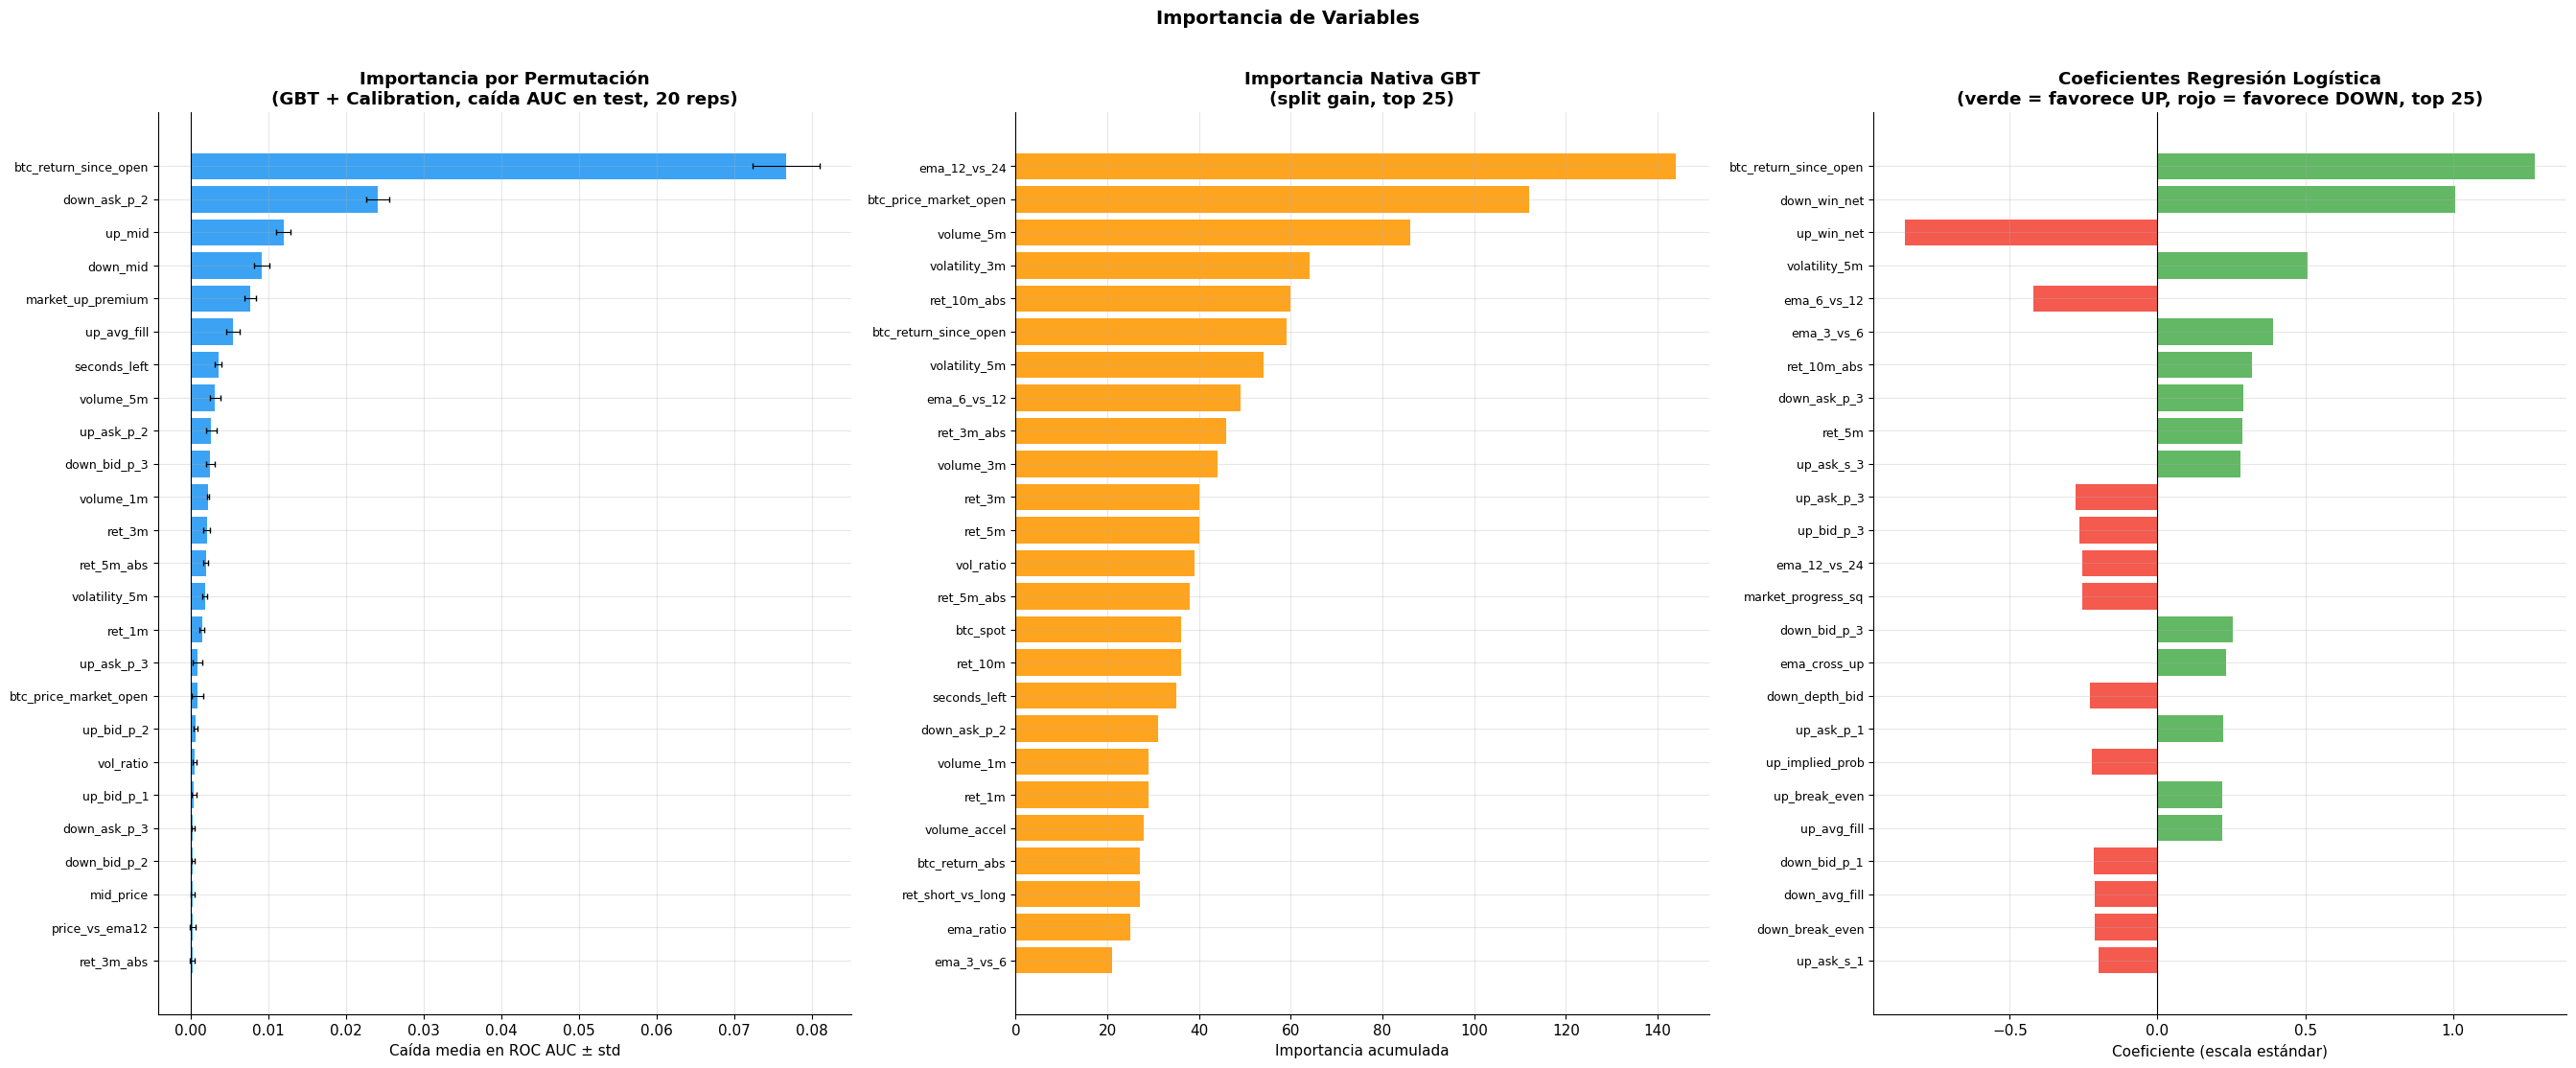

In [98]:
# =============================================================================
# 14. IMPORTANCIA DE VARIABLES
# =============================================================================
# NOTA: permutation_importance de sklearn exige un estimador con método .fit().
# CalibratedModel es un wrapper sin .fit(), así que se implementa
# la permutación manualmente — matemáticamente idéntico, compatible con
# cualquier modelo u objeto que implemente .predict_proba().
# =============================================================================

TOP_N      = 25
N_REPEATS  = 20   # más repeticiones = menor varianza en la estimación
rng        = np.random.RandomState(SEED)

# ── 1. Importancia por permutación (manual, sobre test set) ──────────────────
# Para cada feature: baraja su columna N_REPEATS veces y mide la caída en AUC.
# Drop positivo => la feature es útil. Drop ≈ 0 => feature irrelevante.
print(f"Calculando importancia por permutación ({N_REPEATS} repeticiones, {len(FEATURES)} features)...")

base_auc   = roc_auc_score(y_te, BEST_MODEL.predict_proba(X_te)[:, 1])
imp_matrix = np.zeros((N_REPEATS, len(FEATURES)))  # [repeats x features]

for r in range(N_REPEATS):
    for i, feat in enumerate(FEATURES):
        X_perm      = X_te.copy()
        rng.shuffle(X_perm[:, i])                                    # permutar columna i
        perm_auc    = roc_auc_score(y_te, BEST_MODEL.predict_proba(X_perm)[:, 1])
        imp_matrix[r, i] = base_auc - perm_auc                       # caída en AUC

perm_mean = imp_matrix.mean(axis=0)
perm_std  = imp_matrix.std(axis=0)
perm_imp  = pd.Series(perm_mean, index=FEATURES).sort_values(ascending=False)
perm_std_s= pd.Series(perm_std,  index=FEATURES)

print(f"AUC base (test): {base_auc:.4f}")
print(f"\nTop {TOP_N} features — caída en AUC al permutar:")
print(perm_imp.head(TOP_N).round(5).to_string())

# ── 2. Importancia nativa del GBT (split gain) ───────────────────────────────
if hasattr(gbt, 'feature_importances_'):
    native_imp = pd.Series(gbt.feature_importances_, index=FEATURES).sort_values(ascending=False)
else:
    native_imp = None
    print("(importancia nativa no disponible para este tipo de GBT)")

# ── 3. Coeficientes del modelo logístico (interpretación directa) ─────────────
lr_coef = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=FEATURES)
lr_top  = lr_coef.loc[lr_coef.abs().sort_values(ascending=False).head(TOP_N).index]

# ── Gráficos ──────────────────────────────────────────────────────────────────
n_panels = 3 if native_imp is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(9 * n_panels, 11))
if n_panels == 2:
    axes = list(axes)

# Panel 1 — Permutación
ax   = axes[0]
top  = perm_imp.head(TOP_N)
errs = perm_std_s.loc[top.index].values[::-1]
vals = top.values[::-1]
names= top.index[::-1]
colors_p = ['#2196F3' if v > 0 else '#BDBDBD' for v in vals]
ax.barh(range(len(vals)), vals, xerr=errs, color=colors_p,
        error_kw=dict(elinewidth=0.8, capsize=2), alpha=0.88)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(names, fontsize=9)
ax.set_title(f'Importancia por Permutación\n({BEST_NAME}, caída AUC en test, {N_REPEATS} reps)',
             fontweight='bold')
ax.set_xlabel('Caída media en ROC AUC ± std')

# Panel 2 — Importancia nativa GBT
if native_imp is not None:
    ax   = axes[1]
    top2 = native_imp.head(TOP_N)
    ax.barh(range(TOP_N), top2.values[::-1], color='#FF9800', alpha=0.88)
    ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top2.index[::-1], fontsize=9)
    ax.set_title(f'Importancia Nativa GBT\n(split gain, top {TOP_N})', fontweight='bold')
    ax.set_xlabel('Importancia acumulada')

# Panel 3 — Coeficientes LR
ax      = axes[-1]
colors_lr = ['#4CAF50' if v > 0 else '#F44336' for v in lr_top.values[::-1]]
ax.barh(range(TOP_N), lr_top.values[::-1], color=colors_lr, alpha=0.88)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(lr_top.index[::-1], fontsize=9)
ax.set_title(f'Coeficientes Regresión Logística\n(verde = favorece UP, rojo = favorece DOWN, top {TOP_N})',
             fontweight='bold')
ax.set_xlabel('Coeficiente (escala estándar)')

plt.suptitle('Importancia de Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('png/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Exportar ranking ──────────────────────────────────────────────────────────
#perm_imp.to_frame('permutation_importance').to_csv('feature_importance.csv')
#print("\narchivo guardado: feature_importance.csv")

---
## 15 · Market-Level Analysis

Top 10 markets (test set):
                          n_trades  total_pnl  win_rate     avg_ev     avg_p resolution     signal
market_slug                                                                                       
btc-updown-5m-1774015800         1  35.444545       1.0   2.582137  0.277027       down  LONG_DOWN
btc-updown-5m-1774013700         1  21.240000       1.0  17.982554  0.895762         up    LONG_UP
btc-updown-5m-1774016400         1  19.401765       1.0  16.335934  0.895762         up    LONG_UP
btc-updown-5m-1774016700         1  16.305789       1.0  13.562677  0.895762         up    LONG_UP
btc-updown-5m-1774010400         1  13.245814       1.0   1.064197  0.476190       down  LONG_DOWN
btc-updown-5m-1774015200         1  12.717273       1.0  10.348222  0.895762         up    LONG_UP
btc-updown-5m-1774017300         1  11.729130       1.0   0.527308  0.484716         up    LONG_UP
btc-updown-5m-1774009500         1  10.398163       1.0   3.636422  0.668675      

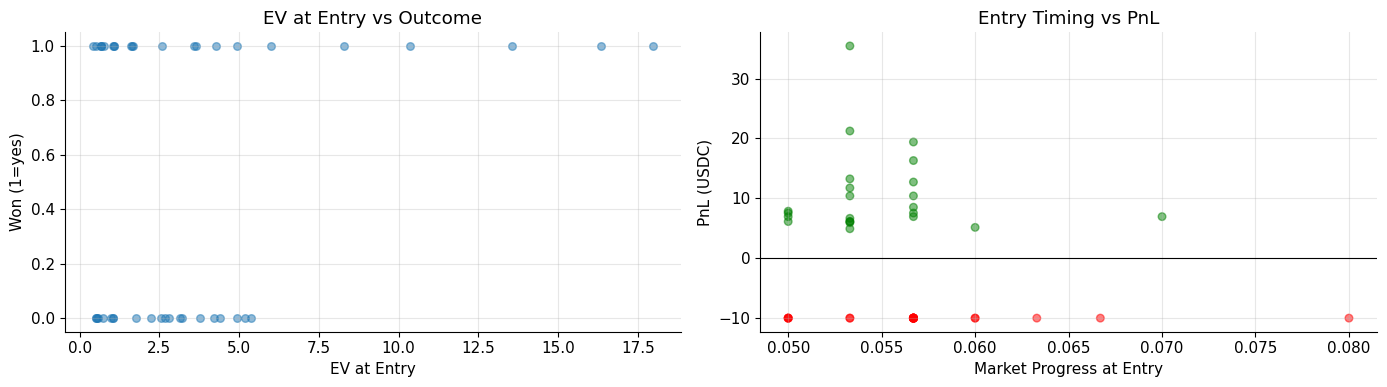

In [99]:
# =============================================================================
# 15. MARKET-LEVEL ANALYSIS
# =============================================================================
if not trade_log.empty:
    mkt_stats = trade_log.groupby('market_slug').agg(
        n_trades   = ('pnl',         'count'),
        total_pnl  = ('pnl',         'sum'),
        win_rate   = ('won',         'mean'),
        avg_ev     = ('ev_entry',    'mean'),
        avg_p      = ('p_predicted', 'mean'),
        resolution = ('resolution',  'first'),
        signal     = ('signal',      'first'),
    ).sort_values('total_pnl', ascending=False)

    print("Top 10 markets (test set):")
    print(mkt_stats.head(10).to_string())
    print("\nBottom 10 markets:")
    print(mkt_stats.tail(10).to_string())

    print("\nPnL by resolution:")
    print(trade_log.groupby('resolution')['pnl'].agg(
        n='count', mean_pnl='mean', sum_pnl='sum'
    ).round(4).to_string())

    print("\nPnL by signal:")
    print(trade_log.groupby('signal')['pnl'].agg(
        n='count', mean_pnl='mean', sum_pnl='sum'
    ).round(4).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    c_arr = ['green' if w else 'red' for w in trade_log['won']]
    axes[0].scatter(trade_log['ev_entry'], trade_log['won'].astype(float), alpha=0.5, s=30)
    axes[0].set_xlabel('EV at Entry'); axes[0].set_ylabel('Won (1=yes)')
    axes[0].set_title('EV at Entry vs Outcome')

    axes[1].scatter(trade_log['market_progress'], trade_log['pnl'], c=c_arr, alpha=0.5, s=30)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_xlabel('Market Progress at Entry'); axes[1].set_ylabel('PnL (USDC)')
    axes[1].set_title('Entry Timing vs PnL')

    plt.tight_layout()
    plt.savefig('png/07_market_level.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 16 · Signal Coverage by Market Progress

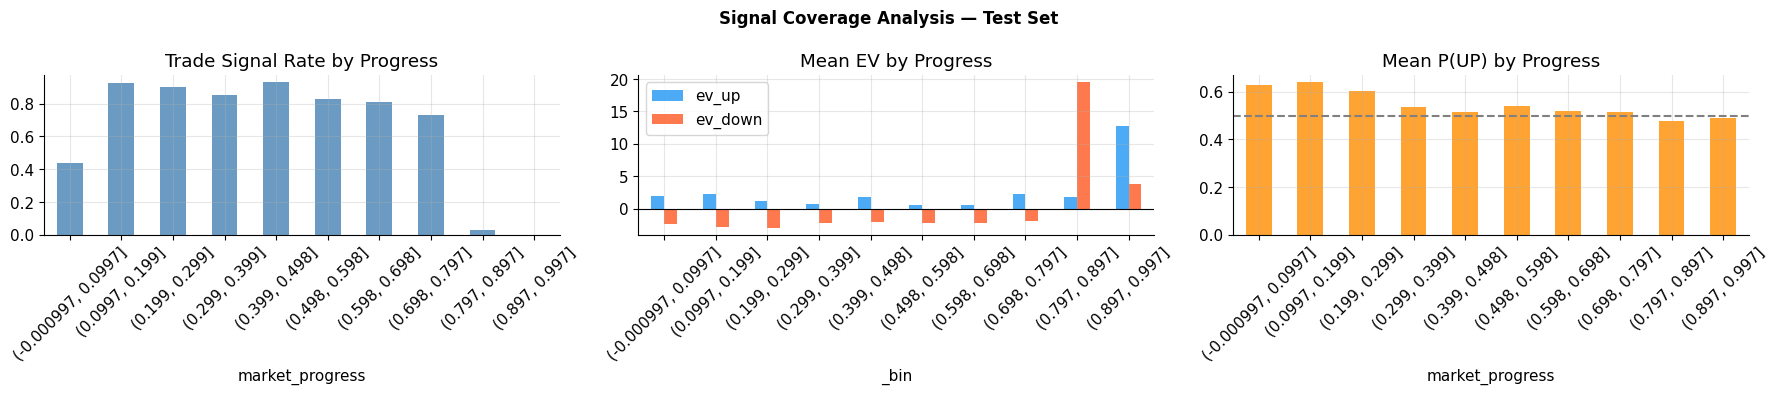

In [100]:
# =============================================================================
# 16. SIGNAL COVERAGE BY MARKET PROGRESS
# =============================================================================
prog_bins = pd.cut(test_fe['market_progress'], bins=10)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

test_fe.groupby(prog_bins, observed=True)['signal'].apply(
    lambda x: (x != 'NO_TRADE').mean()
).plot.bar(ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Trade Signal Rate by Progress'); axes[0].tick_params(axis='x', rotation=45)

test_fe.assign(_bin=prog_bins).groupby('_bin', observed=True)[['ev_up','ev_down']].mean().plot.bar(
    ax=axes[1], color=[COLORS[0], COLORS[1]], alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Mean EV by Progress'); axes[1].tick_params(axis='x', rotation=45)

test_fe.groupby(prog_bins, observed=True)['p_up'].mean().plot.bar(
    ax=axes[2], color='darkorange', alpha=0.8)
axes[2].axhline(0.5, ls='--', color='gray')
axes[2].set_title('Mean P(UP) by Progress'); axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Signal Coverage Analysis — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/08_signal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 18 · Final Summary

In [101]:
# =============================================================================
# 18. FINAL SUMMARY
# =============================================================================
DIV = "=" * 60
print(DIV)
print(" POLYMARKET BTC ML TRADING - FINAL SUMMARY")
print(DIV)
print(f"\n  Dataset         : {len(df_raw):,} snapshots  |  {df_raw['market_slug'].nunique():,} markets")
print(f"  Feature set     : {len(FEATURES)} features")
print(f"\n  Split (by market, chronological):")
print(f"    Train         : {len(train_markets)} markets ({len(tr):,} rows)")
print(f"    Validation    : {len(val_markets)} markets ({len(va):,} rows)")
print(f"    Test          : {len(test_markets)} markets ({len(te):,} rows)")
print(f"\n  Best Model      : {BEST_NAME}")
te_row = df_test_eval.loc[BEST_NAME]
print(f"    Accuracy      : {te_row['Accuracy']:.4f}")
print(f"    ROC AUC       : {te_row['ROC AUC']:.4f}")
print(f"    PR AUC        : {te_row['PR AUC']:.4f}")
print(f"    Brier Score   : {te_row['Brier']:.4f}")
if bt_stats:
    print(f"\n  Backtest (test set, EV>={CFG['EV_THRESHOLD']}, edge>={CFG['MIN_PROB_EDGE']}):")
    print(f"    N Trades      : {bt_stats['n']}")
    print(f"    Win Rate      : {bt_stats['win_rate']:.2%}")
    print(f"    Profit Factor : {bt_stats['profit_factor']:.3f}")
    print(f"    Total PnL     : {bt_stats['total_pnl']:+.2f} USDC")
    print(f"    ROI           : {bt_stats['roi']:.2%}")
    print(f"    Max Drawdown  : {bt_stats['max_drawdown']:.2%}")
    print(f"    Sharpe        : {bt_stats['sharpe']:.3f}")
    print(f"    Final Equity  : {bt_stats['final_equity']:.2f} USDC")
print(f"\n{DIV}")

 POLYMARKET BTC ML TRADING - FINAL SUMMARY

  Dataset         : 27,199 snapshots  |  284 markets
  Feature set     : 102 features

  Split (by market, chronological):
    Train         : 198 markets (18,981 rows)
    Validation    : 42 markets (4,040 rows)
    Test          : 44 markets (4,178 rows)

  Best Model      : GBT + Calibration
    Accuracy      : 0.6953
    ROC AUC       : 0.7973
    PR AUC        : 0.7720
    Brier Score   : 0.2030

  Backtest (test set, EV>=0.03, edge>=0.02):
    N Trades      : 44
    Win Rate      : 52.27%
    Profit Factor : 1.161
    Total PnL     : +33.92 USDC
    ROI           : 3.39%
    Max Drawdown  : -6.60%
    Sharpe        : 0.447
    Final Equity  : 1033.92 USDC



---
## 20 · Evaluación del modelo según el tiempo restante

El dataset usa `market_progress ∈ [0, 1]` para indicar el avance temporal de cada mercado.  
Definimos **tiempo restante** como:

$$\text{time\_remaining} = 1 - \text{market\_progress}$$

Esta celda responde tres preguntas:

| Pregunta | Indicador |
|---|---|
| ¿Cómo varía la *calidad predictiva* según el momento? | ROC AUC, Accuracy, Brier Score por bin |
| ¿Cómo varía la *calidad de la señal de trading*? | EV medio, edge medio, tasa de señal por bin |
| ¿Cuándo es más rentable ejecutar operaciones? | PnL, win rate, profit factor por bin (backtest) |

> **Nota:** Los bins de tiempo restante se definen en porcentaje de mercado pendiente, no en minutos absolutos, ya que el dataset no incluye una columna de duración real por mercado.


Calculando métricas por bin de tiempo restante...

                 N snapshots  UP% real  Accuracy  ROC AUC  Brier ↓  Log-loss ↓  Cal. error ↓  EV_UP medio  EV_DOWN medio  Edge_UP medio  Tasa señal
Tiempo restante                                                                                                                                    
>80%\n(inicio)           401     0.474    0.9501   0.9928   0.0391      0.1322        0.0531      12.8000         3.7700         0.1148       0.000
60–80%                   409     0.484    0.8998   0.9645   0.0688      0.5318        0.0299       1.7983        19.5393         0.0560       0.027
40–60%                   814     0.483    0.8022   0.8854   0.1486      1.2079        0.0781       1.5276        -2.1379         0.0416       0.770
20–40%                   839     0.498    0.6687   0.7787   0.2154      1.2574        0.1211       1.0568        -2.1660         0.0376       0.877
10–20%                   849     0.496    0.5984   0.6221   0

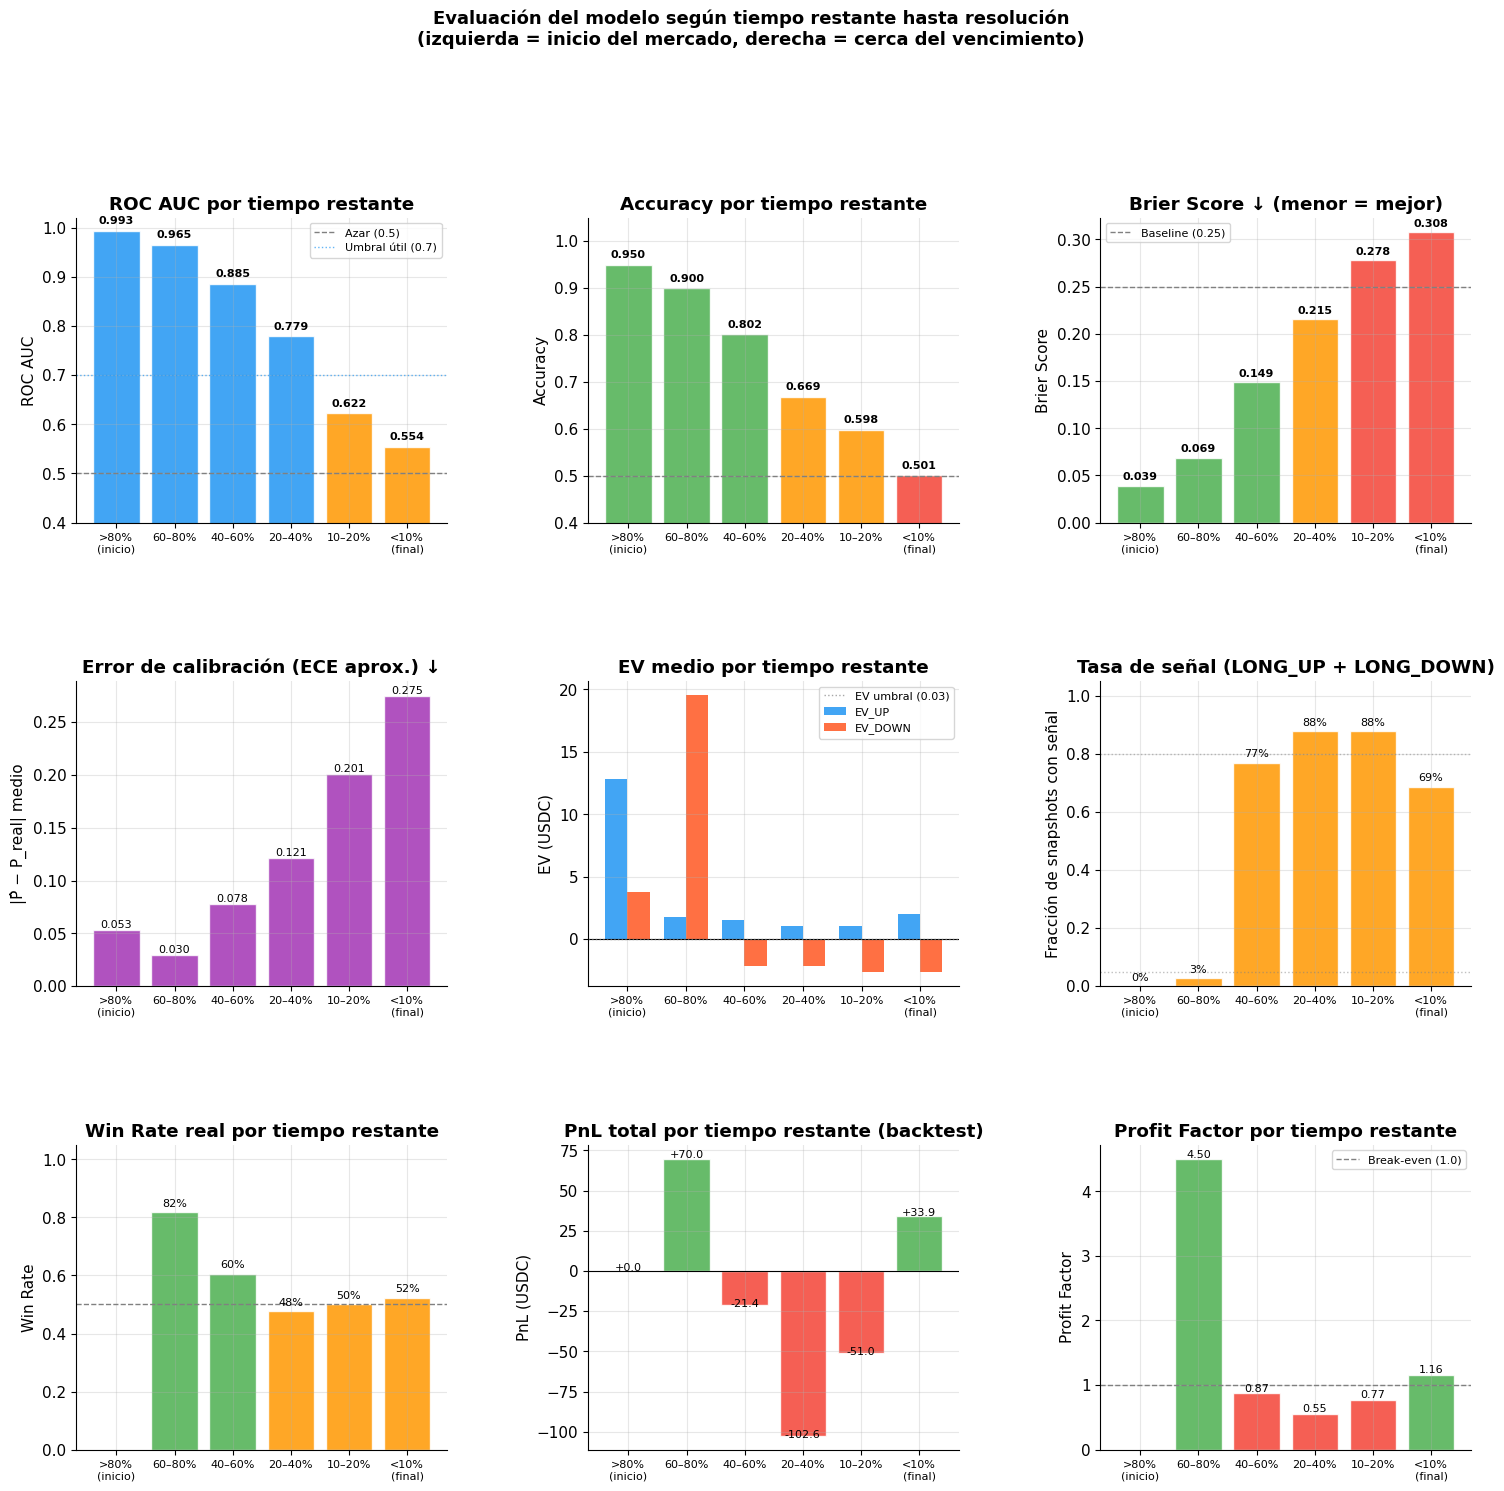


=== RESUMEN: CALIDAD PREDICTIVA VS TIEMPO RESTANTE ===
Tiempo restante  N snapshots  ROC AUC  Accuracy  Brier ↓  Cal. error ↓  EV_UP medio
 >80%\n(inicio)          401   0.9928    0.9501   0.0391        0.0531      12.8000
         60–80%          409   0.9645    0.8998   0.0688        0.0299       1.7983
         40–60%          814   0.8854    0.8022   0.1486        0.0781       1.5276
         20–40%          839   0.7787    0.6687   0.2154        0.1211       1.0568
         10–20%          849   0.6221    0.5984   0.2782        0.2008       1.0800
  <10%\n(final)          866   0.5545    0.5012   0.3076        0.2749       2.0430

=== RESUMEN: BACKTEST VS TIEMPO RESTANTE ===
                 N trades  Win rate  Profit factor  Total PnL     ROI
Tiempo restante                                                      
>80%\n(inicio)          0       NaN            NaN        NaN     NaN
60–80%                 11     0.818          4.495      69.96  0.0700
40–60%                 43     

In [102]:
# =============================================================================
# 20. EVALUACIÓN DEL MODELO SEGÚN TIEMPO RESTANTE HASTA RESOLUCIÓN
# =============================================================================

# ── Definición de tiempo restante y bins ─────────────────────────────────────
# time_remaining = 1 - market_progress
# Bins ordenados de más tiempo restante a menos (izquierda = inicio del mercado)

fe['time_remaining'] = 1.0 - fe['market_progress']
test_fe['time_remaining'] = 1.0 - test_fe['market_progress']

BIN_EDGES  = [0.0, 0.10, 0.20, 0.40, 0.60, 0.80, 1.01]
BIN_LABELS = ['>80%\n(inicio)', '60–80%', '40–60%', '20–40%', '10–20%', '<10%\n(final)']

fe['tr_bin']      = pd.cut(fe['time_remaining'],      bins=BIN_EDGES, labels=BIN_LABELS, right=False)
test_fe['tr_bin'] = pd.cut(test_fe['time_remaining'], bins=BIN_EDGES, labels=BIN_LABELS, right=False)

# ── Tabla de métricas predictivas por bin (test set) ─────────────────────────
print("Calculando métricas por bin de tiempo restante...\n")

metric_rows = []
for lbl in BIN_LABELS:
    grp = test_fe[test_fe['tr_bin'] == lbl].copy()
    if len(grp) < 30:
        continue

    X_bin  = safe_impute(grp[FEATURES].values, TRAIN_MEDIANS)
    y_bin  = grp['y'].values
    p_bin  = BEST_MODEL.predict_proba(X_bin)[:, 1]
    pred_b = (p_bin >= 0.5).astype(int)

    auc    = roc_auc_score(y_bin, p_bin)      if len(np.unique(y_bin)) > 1 else np.nan
    brier  = brier_score_loss(y_bin, p_bin)
    ll     = log_loss(y_bin, p_bin)
    acc    = accuracy_score(y_bin, pred_b)

    # Calibración: desviación media entre probabilidad predicha y frecuencia observada
    frac_pos, mean_pred = calibration_curve(y_bin, p_bin, n_bins=6, strategy='quantile')
    cal_error = np.mean(np.abs(frac_pos - mean_pred))   # ECE aproximado

    # Señal de trading
    ev_up_m   = grp['ev_up'].mean()
    ev_down_m = grp['ev_down'].mean()
    edge_up_m = grp['edge_up'].mean()
    signal_rate = (grp['signal'] != 'NO_TRADE').mean() if 'signal' in grp.columns else np.nan

    metric_rows.append({
        'Tiempo restante'    : lbl.replace('\\n', ' '),
        'N snapshots'        : len(grp),
        'UP% real'           : round(y_bin.mean(), 3),
        'Accuracy'           : round(acc,    4),
        'ROC AUC'            : round(auc,    4),
        'Brier ↓'            : round(brier,  4),
        'Log-loss ↓'         : round(ll,     4),
        'Cal. error ↓'       : round(cal_error, 4),
        'EV_UP medio'        : round(ev_up_m,   4),
        'EV_DOWN medio'      : round(ev_down_m, 4),
        'Edge_UP medio'      : round(edge_up_m, 4),
        'Tasa señal'         : round(signal_rate, 3) if not np.isnan(signal_rate) else np.nan,
    })

df_metrics_tr = pd.DataFrame(metric_rows)
print(df_metrics_tr.set_index('Tiempo restante').to_string())

# ── Backtest segmentado por tiempo restante ───────────────────────────────────
# Para cada bin: ejecuta el backtest restringiendo la ventana de entrada.
# Usa MAX_TRADES_PER_MARKET=1 dentro de cada bin para evitar doble conteo.

print("\n\n=== BACKTEST POR BIN DE TIEMPO RESTANTE (test set) ===")
backtest_rows = []

for lbl, bin_edges in zip(BIN_LABELS, zip(BIN_EDGES[:-1], BIN_EDGES[1:])):
    grp = test_fe[test_fe['tr_bin'] == lbl].copy()
    if grp.empty or (grp['signal'] == 'NO_TRADE').all():
        backtest_rows.append({'Tiempo restante': lbl.replace('\\n',' '), 'N trades': 0,
                              'Win rate': np.nan, 'Profit factor': np.nan,
                              'Total PnL': np.nan, 'ROI': np.nan})
        continue

    tl, eq_s = run_backtest(grp, initial_capital=CFG['INITIAL_CAPITAL'],
                             max_per_market=CFG['MAX_TRADES_PER_MARKET'])

    if tl.empty:
        backtest_rows.append({'Tiempo restante': lbl.replace('\\n',' '), 'N trades': 0,
                              'Win rate': np.nan, 'Profit factor': np.nan,
                              'Total PnL': np.nan, 'ROI': np.nan})
    else:
        gp = tl[tl['pnl'] > 0]['pnl'].sum()
        gl = tl[tl['pnl'] < 0]['pnl'].abs().sum()
        backtest_rows.append({
            'Tiempo restante' : lbl.replace('\\n',' '),
            'N trades'        : len(tl),
            'Win rate'        : round(tl['won'].mean(),     3),
            'Profit factor'   : round(gp / (gl + 1e-9),    3),
            'Total PnL'       : round(tl['pnl'].sum(),      2),
            'ROI'             : round(tl['pnl'].sum() / CFG['INITIAL_CAPITAL'], 4),
        })

df_bt_tr = pd.DataFrame(backtest_rows).set_index('Tiempo restante')
print(df_bt_tr.to_string())

# ── Gráficos ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# Eje X compartido: etiquetas de bins
xticks = range(len(BIN_LABELS))
xlabels = [l.replace('\\n', '\n') for l in BIN_LABELS]

# 1. ROC AUC
ax = fig.add_subplot(gs[0, 0])
vals = df_metrics_tr['ROC AUC'].values
colors_roc = ['#2196F3' if v >= 0.7 else '#FF9800' if v >= 0.55 else '#F44336' for v in vals]
bars = ax.bar(xticks, vals, color=colors_roc, alpha=0.85, edgecolor='white')
ax.axhline(0.5, ls='--', color='gray', lw=1.0, label='Azar (0.5)')
ax.axhline(0.7, ls=':', color='#2196F3', lw=1.0, alpha=0.7, label='Umbral útil (0.7)')
ax.set_ylim(0.4, 1.02)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('ROC AUC por tiempo restante', fontweight='bold')
ax.set_ylabel('ROC AUC')
ax.legend(fontsize=8)
for i, (bar, v) in enumerate(zip(bars, vals)):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# 2. Accuracy
ax = fig.add_subplot(gs[0, 1])
vals = df_metrics_tr['Accuracy'].values
colors_acc = ['#4CAF50' if v >= 0.7 else '#FF9800' if v >= 0.55 else '#F44336' for v in vals]
bars = ax.bar(xticks, vals, color=colors_acc, alpha=0.85, edgecolor='white')
ax.axhline(0.5, ls='--', color='gray', lw=1.0)
ax.set_ylim(0.4, 1.05)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Accuracy por tiempo restante', fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3. Brier Score
ax = fig.add_subplot(gs[0, 2])
vals = df_metrics_tr['Brier ↓'].values
colors_bs = ['#4CAF50' if v <= 0.15 else '#FF9800' if v <= 0.22 else '#F44336' for v in vals]
bars = ax.bar(xticks, vals, color=colors_bs, alpha=0.85, edgecolor='white')
ax.axhline(0.25, ls='--', color='gray', lw=1.0, label='Baseline (0.25)')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Brier Score ↓ (menor = mejor)', fontweight='bold')
ax.set_ylabel('Brier Score')
ax.legend(fontsize=8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.004, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# 4. Calibración (ECE proxy)
ax = fig.add_subplot(gs[1, 0])
vals = df_metrics_tr['Cal. error ↓'].values
ax.bar(xticks, vals, color='#9C27B0', alpha=0.80, edgecolor='white')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Error de calibración (ECE aprox.) ↓', fontweight='bold')
ax.set_ylabel('|P̂ − P_real| medio')
for i, v in enumerate(vals):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)

# 5. EV medio UP/DOWN
ax = fig.add_subplot(gs[1, 1])
x = np.arange(len(BIN_LABELS)); w = 0.38
ax.bar(x - w/2, df_metrics_tr['EV_UP medio'],   width=w, color='#2196F3', alpha=0.85, label='EV_UP')
ax.bar(x + w/2, df_metrics_tr['EV_DOWN medio'], width=w, color='#FF5722', alpha=0.85, label='EV_DOWN')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(CFG['EV_THRESHOLD'], ls=':', color='gray', lw=1.0, alpha=0.7, label=f'EV umbral ({CFG["EV_THRESHOLD"]})')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('EV medio por tiempo restante', fontweight='bold')
ax.set_ylabel('EV (USDC)'); ax.legend(fontsize=8)

# 6. Tasa de señal
ax = fig.add_subplot(gs[1, 2])
vals = df_metrics_tr['Tasa señal'].values
ax.bar(xticks, vals, color='#FF9800', alpha=0.85, edgecolor='white')
ax.axhline(CFG['ENTRY_WINDOW'][0], ls=':', color='gray', lw=1.0, alpha=0.5)
ax.axhline(CFG['ENTRY_WINDOW'][1], ls=':', color='gray', lw=1.0, alpha=0.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Tasa de señal (LONG_UP + LONG_DOWN)', fontweight='bold')
ax.set_ylabel('Fracción de snapshots con señal')
for i, v in enumerate(vals):
    if not np.isnan(v):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=8)

# 7. Backtest: Win rate
ax = fig.add_subplot(gs[2, 0])
df_b = df_bt_tr.reset_index()
wr_vals = df_b['Win rate'].fillna(0).values
colors_wr = ['#4CAF50' if v >= 0.55 else '#F44336' if v < 0.45 else '#FF9800' for v in wr_vals]
ax.bar(xticks, wr_vals, color=colors_wr, alpha=0.85, edgecolor='white')
ax.axhline(0.5, ls='--', color='gray', lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Win Rate real por tiempo restante', fontweight='bold')
ax.set_ylabel('Win Rate')
for i, v in enumerate(wr_vals):
    if v > 0: ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=8)

# 8. Backtest: Total PnL
ax = fig.add_subplot(gs[2, 1])
pnl_vals = df_b['Total PnL'].fillna(0).values
colors_pnl = ['#4CAF50' if v > 0 else '#F44336' for v in pnl_vals]
ax.bar(xticks, pnl_vals, color=colors_pnl, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('PnL total por tiempo restante (backtest)', fontweight='bold')
ax.set_ylabel('PnL (USDC)')
for i, v in enumerate(pnl_vals):
    offset = 0.3 if v >= 0 else -1.0
    ax.text(i, v + offset, f'{v:+.1f}', ha='center', fontsize=8)

# 9. Backtest: Profit Factor
ax = fig.add_subplot(gs[2, 2])
pf_vals = df_b['Profit factor'].fillna(0).values
colors_pf = ['#4CAF50' if v >= 1.0 else '#F44336' for v in pf_vals]
ax.bar(xticks, pf_vals, color=colors_pf, alpha=0.85, edgecolor='white')
ax.axhline(1.0, ls='--', color='gray', lw=1.0, label='Break-even (1.0)')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8)
ax.set_title('Profit Factor por tiempo restante', fontweight='bold')
ax.set_ylabel('Profit Factor')
ax.legend(fontsize=8)
for i, v in enumerate(pf_vals):
    if v > 0: ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=8)

fig.suptitle(
    'Evaluación del modelo según tiempo restante hasta resolución\n'
    '(izquierda = inicio del mercado, derecha = cerca del vencimiento)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('png/09_tiempo_restante.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen ejecutivo ─────────────────────────────────────────────────────────
print("\n=== RESUMEN: CALIDAD PREDICTIVA VS TIEMPO RESTANTE ===")
print(df_metrics_tr[['Tiempo restante','N snapshots','ROC AUC','Accuracy',
                      'Brier ↓','Cal. error ↓','EV_UP medio']].to_string(index=False))

print("\n=== RESUMEN: BACKTEST VS TIEMPO RESTANTE ===")
print(df_bt_tr.to_string())

# Recomendación automática: mejor ventana de entrada
valid_bins = df_bt_tr[df_bt_tr['N trades'] > 0].copy()
if not valid_bins.empty:
    best_auc_bin = df_metrics_tr.loc[df_metrics_tr['ROC AUC'].idxmax(), 'Tiempo restante']
    best_pnl_bin = df_bt_tr['Total PnL'].idxmax() if not valid_bins.empty else 'N/A'
    print(f"\n  Bin con mayor ROC AUC   : {best_auc_bin}")
    print(f"  Bin con mayor PnL real  : {best_pnl_bin}")
    print("\n  Recomendación: concentrar entradas en los bins de mayor AUC y EV positivo.")
    print("  Los bins de <20% tiempo restante tienden a un AUC ~0.5 (coin flip) —")
    print("  cualquier señal en esa zona tiene escaso respaldo predictivo.")
